# Bank IRRBB & Liquidity Report

**Report Date:** 2026-06-30  
**Currency:** PLN (primary)  
**Purpose:** Executive overview — balance sheet, interest rate risk, liquidity and behavioural model outputs.

---
| # | Section |
|---|---|
| 1 | Balance Sheet Summary |
| 2 | Market Yield Curves |
| 2b | IRRBB Scenario Yield Curves (base + 6 EBA shocks) |
| 3 | Interest Rate Repricing Gap |
| 4 | Liquidity Gap |
| 5 | Behavioural Run-off |
| 7 | EBA IRRBB SOT — ΔEVE & ΔNII |
| 8 | LCR & NSFR |
| 10 | Non-linearity Analysis (NII & EVE) |


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sqlalchemy import create_engine, text
from IPython.display import HTML, display

ENGINE = create_engine(
    'mssql+pyodbc://maciek_d/bank_gen'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&Trusted_Connection=yes',
    future=True,
)
REPORT_DATE = pd.to_datetime('2026-06-30')
CCY = 'PLN'

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.titlepad': 8,
    'legend.fontsize': 8,
    'legend.framealpha': 0.8,
})

# ── Color palette ────────────────────────────────────────────────────────────
C_A  = '#1565C0'   # asset / positive
C_L  = '#C62828'   # liability / negative
C_N  = '#2E7D32'   # net
C_EQ = '#6A1B9A'   # equity
C_UP = '#D32F2F'   # rate-up shock
C_DN = '#1565C0'   # rate-down shock
C_OK = '#2E7D32'   # compliant
C_WN = '#E65100'   # warning
C_GR = '#455A64'   # grey / neutral

BLUES  = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9', '#BBDEFB']
REDS   = ['#C62828', '#D32F2F', '#EF5350', '#EF9A9A', '#FFCDD2']

# ── Helpers ──────────────────────────────────────────────────────────────────
def rsql(q, **p):
    return pd.read_sql_query(text(q), ENGINE, params=p)

def tkey(lbl):
    """Sort key for tenor bucket labels."""
    if lbl == '1D': return 0
    if lbl == '>30Y': return 999_999
    if lbl.endswith('Y'): return int(lbl[:-1]) * 12
    if lbl.endswith('M'): return int(lbl[:-1])
    return 99_999

def sbkt(df, col='tenor_bucket'):
    return df.assign(_s=df[col].map(tkey)).sort_values('_s').drop(columns='_s')

def pct_fmt(v, _=None): return f'{v:.0f}%'
def bn_fmt(v, _=None):  return f'{v:.1f}B'
def mn_fmt(v, _=None):  return f'{v:.0f}M'

# ── Shared HTML table renderer (used instead of raw print() tables) ──────────
_TBL_HEAD_BG  = '#37474F'
_TBL_ROW_ALT  = '#f4f6f7'
_TBL_BORDER   = '#d5dbde'
_TBL_FONT     = "font-family:'Segoe UI', Arial, sans-serif;"

def html_table(headers, rows, aligns=None, total_row=None, title=None, note=None):
    """Render a list-of-rows table (already-formatted strings) as styled HTML.

    headers    : list[str]
    rows       : list[list[str]]   -- pre-formatted cell text, one list per row
                 (a cell may be a (text, color) tuple for conditional coloring)
    aligns     : list['left'|'right'|'center'], defaults to left col0 + right rest
    total_row  : optional list[str] rendered bold with a top border
    title      : optional bold caption above the table
    note       : optional small grey footnote below the table
    """
    n = len(headers)
    aligns = aligns or (['left'] + ['right'] * (n - 1))

    def _th(i):
        return (f'<th style="text-align:{aligns[i]};padding:7px 14px;'
                f'background:{_TBL_HEAD_BG};color:#ffffff;font-weight:600;'
                f'font-size:12.5px;{_TBL_FONT}white-space:nowrap;">{headers[i]}</th>')

    def _td(i, v, bold=False, top_border=False, color=None):
        style = (f'text-align:{aligns[i]};padding:5px 14px;font-size:12.5px;'
                 f'{_TBL_FONT}white-space:nowrap;')
        if bold: style += 'font-weight:700;'
        if top_border: style += f'border-top:2px solid {_TBL_HEAD_BG};'
        if color: style += f'color:{color};'
        return f'<td style="{style}">{v}</td>'

    parts = ['<div style="overflow-x:auto;margin:6px 0 4px 0;">']
    if title:
        parts.append(f'<div style="{_TBL_FONT}font-weight:700;font-size:13.5px;'
                      f'margin-bottom:4px;">{title}</div>')
    parts.append(f'<table style="border-collapse:collapse;border:1px solid {_TBL_BORDER};">')
    parts.append('<thead><tr>' + ''.join(_th(i) for i in range(n)) + '</tr></thead>')
    parts.append('<tbody>')
    for ridx, row in enumerate(rows):
        bg = '#ffffff' if ridx % 2 == 0 else _TBL_ROW_ALT
        cells = []
        for i, cell in enumerate(row):
            if isinstance(cell, tuple):
                v, color = cell
            else:
                v, color = cell, None
            cells.append(_td(i, v, color=color))
        parts.append(f'<tr style="background:{bg};">' + ''.join(cells) + '</tr>')
    if total_row:
        cells = []
        for i, cell in enumerate(total_row):
            v, color = cell if isinstance(cell, tuple) else (cell, None)
            cells.append(_td(i, v, bold=True, top_border=True, color=color))
        parts.append(f'<tr style="background:#eceff1;">' + ''.join(cells) + '</tr>')
    parts.append('</tbody></table>')
    if note:
        parts.append(f'<div style="{_TBL_FONT}font-size:11px;color:#607D8B;'
                      f'margin-top:4px;">{note}</div>')
    parts.append('</div>')
    return HTML(''.join(parts))

def pos_neg(v, fmt):
    """Format a signed number and color it green (C_N) if >=0 else red (C_L)."""
    s = format(v, fmt)
    return (s, C_N if v >= 0 else C_L)

def kpi_row(cards):
    """Render a row of big-number KPI cards.

    cards: list of dicts {label, value, sub (optional), color (optional)}.
    """
    parts = ['<div style="display:flex;flex-wrap:wrap;gap:18px;margin:10px 0 16px 0;">']
    for c in cards:
        color = c.get('color', '#212121')
        sub = (f'<div style="font-size:11px;color:#90A4AE;">{c["sub"]}</div>'
               if c.get('sub') else '')
        parts.append(
            f'<div style="flex:1;min-width:140px;background:{_TBL_ROW_ALT};'
            f'border:1px solid {_TBL_BORDER};border-radius:8px;padding:16px 20px;'
            f'text-align:center;{_TBL_FONT}">'
            f'<div style="font-size:12px;color:#607D8B;font-weight:600;'
            f'letter-spacing:0.4px;text-transform:uppercase;">{c["label"]}</div>'
            f'<div style="font-size:38px;font-weight:700;color:{color};line-height:1.25;">'
            f'{c["value"]}</div>{sub}</div>'
        )
    parts.append('</div>')
    return HTML(''.join(parts))

print(f'Setup complete  |  Report date: {REPORT_DATE.date()}')

Setup complete  |  Report date: 2026-06-30


## Data Loading

In [2]:
RD = REPORT_DATE

# 1. Balance sheet
bs_raw = rsql('''
    SELECT product_name, bs_side, currency, SUM(balance_amt) AS balance_amt
    FROM dbo.transactions
    WHERE report_date = :rd
    GROUP BY product_name, bs_side, currency
''', rd=RD)

equity_amt = float(rsql(
    'SELECT ISNULL(SUM(balance_amt),0) AS v FROM schemat.equity WHERE report_date=:rd',
    rd=RD)['v'].iloc[0])

loan_rt = rsql('''
    SELECT ISNULL(rate_type,'V') AS rate_type, currency, SUM(balance_amt) AS balance_amt
    FROM schemat.loans WHERE bs_side='A' AND report_date=:rd
    GROUP BY rate_type, currency
''', rd=RD)

dep_rt = rsql('''
    SELECT ISNULL(rate_type,'V') AS rate_type, currency, SUM(balance_amt) AS balance_amt
    FROM schemat.deposits WHERE bs_side='L' AND report_date=:rd
    GROUP BY rate_type, currency
''', rd=RD)

# 2. Market yield curves
mkt = rsql('''
    SELECT curve_name, n_days, zero_rate, d_f
    FROM mkt.curves WHERE curve_date=:rd
    ORDER BY curve_name, n_days
''', rd=RD)

# 3. IR repricing gap
try:
    ir_gap = rsql('''
        SELECT currency, bs_side, tenor_bucket,
               bucket_start_dt, bucket_end_dt, cf_end_dt,
               gap_cf,
               ISNULL(gap_cf_ca, 0)  AS gap_cf_ca,
               ISNULL(gap_cf_irs, 0) AS gap_cf_irs
        FROM irrbb.ir_gap_beh
    ''')
except Exception:
    ir_gap = rsql('''
        SELECT currency, bs_side, tenor_bucket,
               bucket_start_dt, bucket_end_dt, cf_end_dt,
               gap_cf, 0.0 AS gap_cf_ca, 0.0 AS gap_cf_irs
        FROM irrbb.ir_gap_beh
    ''')
    print('  ir_gap loaded without IRS/CA columns')

# 4. Liquidity gap
liq_gap = rsql('''
    SELECT currency, bs_side, tenor_bucket,
           bucket_start_dt, bucket_end_dt, cf_end_dt, gap_cf
    FROM irrbb.liq_gap_beh
''')

# 5. Behavioural run-off
# product_code → product_name lookup from dbo.transactions
product_code_map = rsql('''
    SELECT DISTINCT product_code, product_name, bs_side
    FROM dbo.transactions
    WHERE report_date = :rd
''', rd=RD)

runoff = rsql('''
    SELECT product_type, product_code, bs_side, currency, cf_end_dt,
           SUM(ISNULL(beh_capital_pmt,0) + ISNULL(prepayment_pmt,0)) AS beh_cap,
           SUM(ISNULL(con_capital_pmt,0))                             AS con_cap
    FROM cf.products
    WHERE cf_end_dt > :rd AND COALESCE(beh_total_pmt,0) <> 0
    GROUP BY product_type, product_code, bs_side, currency, cf_end_dt
''', rd=RD)
runoff['cf_end_dt'] = pd.to_datetime(runoff['cf_end_dt'])
# enrich with product_name from lookup
runoff = runoff.merge(
    product_code_map[['product_code', 'product_name']].drop_duplicates('product_code'),
    on='product_code', how='left')

# Outstanding balances per product for run-off notional display
outstanding_bal = rsql('''
    SELECT product_code, product_name, bs_side, currency,
           SUM(balance_amt) AS balance_amt
    FROM dbo.transactions
    WHERE report_date = :rd
    GROUP BY product_code, product_name, bs_side, currency
''', rd=RD)

# IRS book: use gap_cf_irs from ir_gap (already loaded)
irs_book = (ir_gap[ir_gap['gap_cf_irs'] != 0]
            .groupby(['currency', 'tenor_bucket'])[['gap_cf', 'gap_cf_irs']]
            .sum().reset_index())

# 6. NII & EVE per scenario
nii_scen = rsql('''
    SELECT scenario_id, currency,
           SUM(nii_interest) AS nii_interest,
           SUM(nii_renewal)  AS nii_renewal,
           SUM(nii_total)    AS nii_total
    FROM irrbb.nii_results WHERE report_date=:rd
    GROUP BY scenario_id, currency
''', rd=RD)

eve_scen = rsql('''
    SELECT scenario_id, currency,
           SUM(pv_capital)  AS pv_capital,
           SUM(pv_interest) AS pv_interest,
           SUM(pv_total)    AS pv_total
    FROM irrbb.eve_results WHERE report_date=:rd
    GROUP BY scenario_id, currency
''', rd=RD)

# 7. IRRBB SOT
try:
    irrbb_sot = rsql('''
        SELECT scenario_id, currency,
               delta_nii, sot_nii_pct, delta_nii_reg, sot_nii_pct_reg,
               delta_eve, sot_eve_pct, delta_eve_reg, sot_eve_pct_reg
        FROM irrbb.irrbb_report WHERE report_date=:rd
    ''', rd=RD)
except Exception as e:
    irrbb_sot = pd.DataFrame()
    print(f'  SOT not available: {e}')

tier1 = float(rsql(
    'SELECT ISNULL(SUM(balance_amt),0) AS v FROM schemat.equity WHERE report_date=:rd',
    rd=RD)['v'].iloc[0])

# 8. LCR / NSFR
try:
    lcr_nsfr = rsql('''
        SELECT currency, hqla, outflows_30d, inflows_30d,
               net_outflows_30d, lcr, asf, rsf, nsfr
        FROM results.lcr_nsfr WHERE report_date=:rd
    ''', rd=RD)
except Exception as e:
    lcr_nsfr = pd.DataFrame()
    print(f'  LCR/NSFR not available: {e}')

print(f'Data loaded  |  {len(bs_raw)} BS rows  |  {ir_gap["tenor_bucket"].nunique()} IR gap buckets  |  '
      f'{nii_scen["scenario_id"].nunique()} NII / {eve_scen["scenario_id"].nunique()} EVE scenarios  |  '
      f'Tier 1 = {tier1/1e9:.2f} B PLN')
# 9. IRRBB shocked curves (for scenario curve plot)
try:
    irrbb_curves = rsql('''
        SELECT scenario_id, curve_name, n_days, d_f, zero_rt
        FROM irrbb.curves
        WHERE report_date = :rd
          AND curve_name = 'PLN_disc_curve'
          AND scenario_id IN ('base','par_up','par_dn','steep','flat','sr_up','sr_dn')
        ORDER BY scenario_id, n_days
    ''', rd=RD)
except Exception as e:
    irrbb_curves = pd.DataFrame()
    print(f'  IRRBB curves not available: {e}')

# 10. NII own scenarios (own_1_up/dn, own_100_up/dn) for non-linearity
try:
    nii_own = rsql('''
        SELECT scenario_id, currency, SUM(nii_total) AS nii_total
        FROM cf.nii_own_scenarios
        WHERE report_date = :rd
        GROUP BY scenario_id, currency
    ''', rd=RD)
except Exception as e:
    nii_own = pd.DataFrame()
    print(f'  NII own scenarios not available: {e}')

# 10b. NII base scenario CF table (consistent base for 1bps delta)
try:
    nii_cf_base = rsql('''
        SELECT scenario_id, currency, SUM(nii_total) AS nii_total
        FROM cf.nii_base_scenario
        WHERE report_date = :rd
        GROUP BY scenario_id, currency
    ''', rd=RD)
except Exception as e:
    nii_cf_base = pd.DataFrame()
    print(f'  NII base CF scenario not available: {e}')

# 11. EVE own scenarios (own_1_up/dn, own_100_up/dn) for non-linearity
try:
    eve_own = rsql('''
        SELECT scenario_id, currency,
               SUM(pv_capital) + SUM(pv_interest) AS pv_total
        FROM cf.eve_own_scenarios
        WHERE report_date = :rd
          AND scenario_id <> 'base'
        GROUP BY scenario_id, currency
    ''', rd=RD)
except Exception as e:
    eve_own = pd.DataFrame()
    print(f'  EVE own scenarios not available: {e}')

Data loaded  |  17 BS rows  |  85 IR gap buckets  |  8 NII / 8 EVE scenarios  |  Tier 1 = 1.20 B PLN


---
## 0. Key Metrics Dashboard

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# KEY METRICS DASHBOARD  — executive snapshot
# ─────────────────────────────────────────────────────────────────────────────
pln_a = bs_raw[(bs_raw['currency'] == CCY) & (bs_raw['bs_side'] == 'A')]['balance_amt'].sum()
pln_l = bs_raw[(bs_raw['currency'] == CCY) & (bs_raw['bs_side'] == 'L')]['balance_amt'].sum()

nii_base = float(nii_scen[(nii_scen['currency'] == CCY) &
                           (nii_scen['scenario_id'] == 'base')]['nii_total'].sum())
eve_base = float(eve_scen[(eve_scen['currency'] == CCY) &
                           (eve_scen['scenario_id'] == 'base')]['pv_total'].sum())

# 1bps NII sensitivity from own scenarios
def _get_1bp(df, sid, col):
    if df.empty: return None
    sub = df[(df['currency'] == CCY) & (df['scenario_id'] == sid)]
    return float(sub[col].sum()) if not sub.empty else None

_n1up_abs  = _get_1bp(nii_own,     'own_1_up', 'nii_total')
_n1dn_abs  = _get_1bp(nii_own,     'own_1_dn', 'nii_total')
_n1base    = _get_1bp(nii_cf_base,  'base',     'nii_total')
# Use cf.nii_base_scenario as base: same write_shocked_cf_products pipeline
# as own scenarios -> consistent delta (irrbb.nii_results uses a different path)
_cf_base   = _n1base if _n1base is not None else nii_base
dnii_1up   = (_n1up_abs - _cf_base) if _n1up_abs is not None else None
dnii_1dn   = (_n1dn_abs - _cf_base) if _n1dn_abs is not None else None

g_1y = ir_gap[(ir_gap['currency'] == CCY) &
              (ir_gap['tenor_bucket'].map(tkey) <= 12)]['gap_cf'].sum()
dnii_up100 = g_1y * 0.01 * 0.5   # approx: avg 6M remaining in 12M horizon

lcr_v  = float(lcr_nsfr['lcr'].mean()) * 100 \
          if not lcr_nsfr.empty and 'lcr' in lcr_nsfr.columns else None
nsfr_v = float((lcr_nsfr['asf'] / lcr_nsfr['rsf'].replace(0, float('nan'))).mean()) * 100 \
          if not lcr_nsfr.empty and 'asf' in lcr_nsfr.columns else None

worst_eve_pct = None
if not irrbb_sot.empty and 'sot_eve_pct_reg' in irrbb_sot.columns:
    worst_eve_pct = float(irrbb_sot[irrbb_sot['currency'] == CCY]['sot_eve_pct_reg'].min())

worst_nii_pct = None
if not irrbb_sot.empty and 'sot_nii_pct_reg' in irrbb_sot.columns:
    worst_nii_pct = float(irrbb_sot[irrbb_sot['currency'] == CCY]['sot_nii_pct_reg'].min())

display(html_table(
    ['Balance Sheet', 'Value'],
    [
        ['Total assets',      f'{pln_a/1e9:.2f}  B PLN'],
        ['Total liabilities', f'{pln_l/1e9:.2f}  B PLN'],
        ['Tier 1 capital',    f'{tier1/1e9:.2f}  B PLN'],
    ],
    title=f'KEY METRICS  |  {CCY}  |  {REPORT_DATE.date()}',
))

_income_rows = [['Base NII', pos_neg(nii_base/1e6, '+.1f')],
                ['Base EVE', pos_neg(eve_base/1e6, '+.1f')]]
if dnii_1up is not None:
    _income_rows.append(['DNII +1bps', pos_neg(dnii_1up/1e6, '+.3f')])
if dnii_1dn is not None:
    _income_rows.append(['DNII -1bps', pos_neg(dnii_1dn/1e6, '+.3f')])
display(html_table(['Income & Value', 'M PLN'], _income_rows))

_gap_sens = 'asset-sensitive' if g_1y >= 0 else 'liability-sensitive'
_irr_rows = [
    ['IR gap ≤12M', pos_neg(g_1y/1e6, '+.1f'), _gap_sens],
    ['Simple DNII +100bp', pos_neg(dnii_up100/1e6, '+.1f'), 'approx, avg remain_yf=0.5'],
]
if worst_eve_pct is not None:
    breach = worst_eve_pct < -15
    _irr_rows.append(['Worst ΔEVE/T1 (reg), threshold -15%',
                       (f'{worst_eve_pct:+.1f}%', C_L if breach else C_N),
                       'BREACH' if breach else 'ok'])
if worst_nii_pct is not None:
    breach = worst_nii_pct < -5
    _irr_rows.append(['Worst ΔNII/T1 (reg), threshold -5%',
                       (f'{worst_nii_pct:+.1f}%', C_L if breach else C_N),
                       'BREACH' if breach else 'ok'])
display(html_table(['Interest Rate Risk', 'Value', 'Note'], _irr_rows,
                    aligns=['left','right','left']))

_liq_rows = []
if lcr_v is not None:
    breach = lcr_v < 100
    _liq_rows.append(['LCR (avg), min 100%', (f'{lcr_v:.1f}%', C_L if breach else C_N),
                       'BREACH' if breach else 'ok'])
if nsfr_v is not None:
    breach = nsfr_v < 100
    _liq_rows.append(['NSFR (avg), min 100%', (f'{nsfr_v:.1f}%', C_L if breach else C_N),
                       'BREACH' if breach else 'ok'])
if _liq_rows:
    display(html_table(['Liquidity', 'Value', 'Note'], _liq_rows,
                        aligns=['left','right','left']))

Balance Sheet,Value
Total assets,10.00 B PLN
Total liabilities,8.80 B PLN
Tier 1 capital,1.20 B PLN


Income & Value,M PLN
Base NII,+528.5
Base EVE,+2095.0
DNII +1bps,+0.232
DNII -1bps,-0.157


Interest Rate Risk,Value,Note
IR gap ≤12M,+1303.0,asset-sensitive
Simple DNII +100bp,+6.5,"approx, avg remain_yf=0.5"
"Worst ΔEVE/T1 (reg), threshold -15%",-10.2%,ok
"Worst ΔNII/T1 (reg), threshold -5%",-3.5%,ok


Liquidity,Value,Note
"LCR (avg), min 100%",279.7%,ok
"NSFR (avg), min 100%",161.5%,ok


---
## 1. Balance Sheet Summary

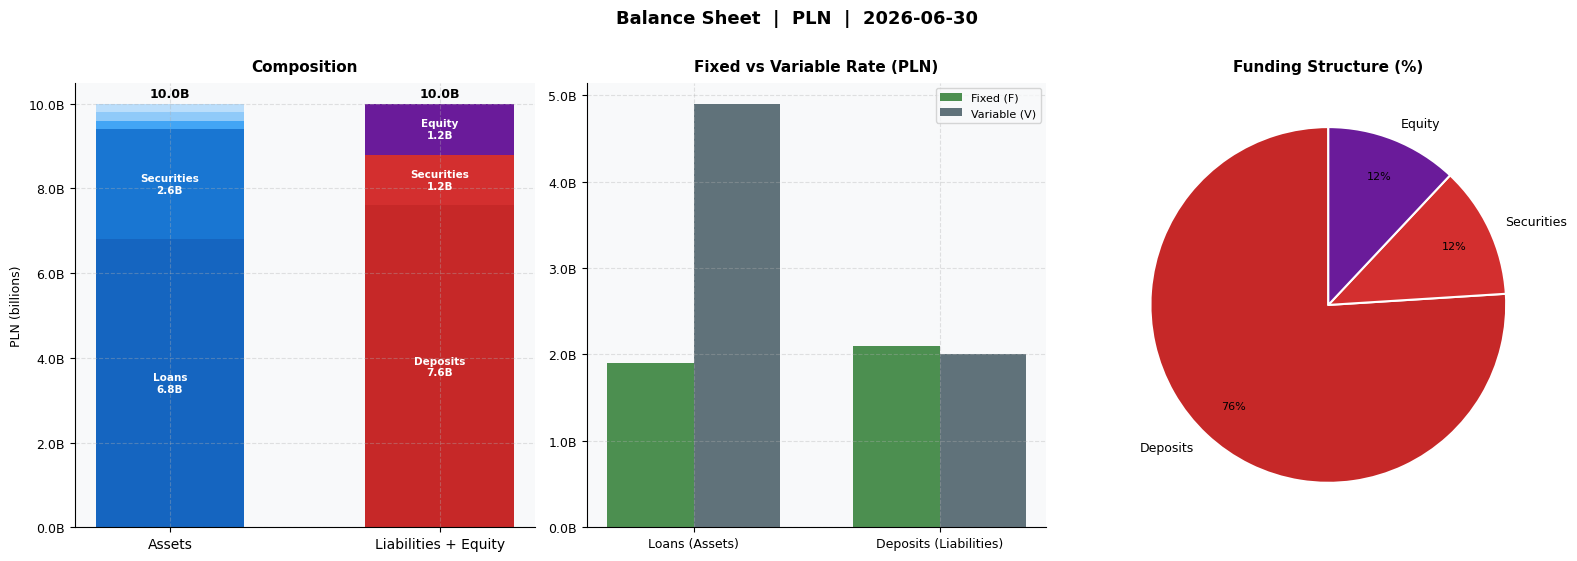

Category,Assets (M),Liabilities (M)
Cash & Placements,200,0
Deposits,200,"7,600"
Loans,"6,800",0
Other,200,0
Securities,"2,600","1,200"
Equity,,"1,200"
TOTAL,"10,000","10,000"


In [4]:
def bs_cat(name):
    n = str(name).lower()
    if any(k in n for k in ('loan','mortgage','overdraft','credit','leasing')): return 'Loans'
    if any(k in n for k in ('bond','security','tbill','fin_inst','treasury')): return 'Securities'
    if any(k in n for k in ('nostro','cash','placement','central','cbm','interbank')): return 'Cash & Placements'
    if any(k in n for k in ('deposit','current_account','saving','account')): return 'Deposits'
    return 'Other'

bs = bs_raw.copy()
bs['cat'] = bs['product_name'].apply(bs_cat)
pln = bs[bs['currency'] == CCY]
assets = pln[pln['bs_side'] == 'A'].groupby('cat')['balance_amt'].sum().sort_values(ascending=False)
liabs  = pln[pln['bs_side'] == 'L'].groupby('cat')['balance_amt'].sum().sort_values(ascending=False)
total_a = assets.sum()
total_l = liabs.sum() + equity_amt

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(f'Balance Sheet  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold', y=1.01)

# Left — T-account stacked bars
ax = axes[0]
bot_a = bot_l = 0.0
for i, (cat, val) in enumerate(assets.items()):
    ax.bar(0, val/1e9, bottom=bot_a/1e9, color=BLUES[i % len(BLUES)], width=0.55)
    if val / total_a > 0.04:
        ax.text(0, (bot_a + val/2)/1e9, f'{cat}\n{val/1e9:.1f}B',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot_a += val
for i, (cat, val) in enumerate(liabs.items()):
    ax.bar(1, val/1e9, bottom=bot_l/1e9, color=REDS[i % len(REDS)], width=0.55)
    if val / total_l > 0.04:
        ax.text(1, (bot_l + val/2)/1e9, f'{cat}\n{val/1e9:.1f}B',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot_l += val
ax.bar(1, equity_amt/1e9, bottom=bot_l/1e9, color=C_EQ, width=0.55)
if equity_amt / total_l > 0.02:
    ax.text(1, (bot_l + equity_amt/2)/1e9, f'Equity\n{equity_amt/1e9:.1f}B',
            ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
ax.text(0, total_a/1e9 + 0.15, f'{total_a/1e9:.1f}B', ha='center', fontweight='bold')
ax.text(1, total_l/1e9 + 0.15, f'{total_l/1e9:.1f}B', ha='center', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Assets', 'Liabilities + Equity'], fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
ax.set_ylabel('PLN (billions)')
ax.set_title('Composition')

# Middle — Fixed vs Variable by side
ax2 = axes[1]
la = loan_rt[loan_rt['currency'] == CCY].set_index('rate_type')['balance_amt']
ld = dep_rt[dep_rt['currency'] == CCY].set_index('rate_type')['balance_amt']
x2 = np.arange(2)
w2 = 0.35
for rt, color, off, lbl in [('F', C_N, -w2/2, 'Fixed (F)'), ('V', C_GR, w2/2, 'Variable (V)')]:
    vals = [la.get(rt, 0)/1e9, ld.get(rt, 0)/1e9]
    ax2.bar(x2 + off, vals, w2, label=lbl, color=color, alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(['Loans (Assets)', 'Deposits (Liabilities)'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
ax2.set_title('Fixed vs Variable Rate (PLN)')
ax2.legend()

# Right — Funding structure pie
ax3 = axes[2]
pie_data = pd.concat([liabs, pd.Series({'Equity': equity_amt})])
pie_colors = REDS[:len(liabs)] + [C_EQ]
wedges, texts, autotexts = ax3.pie(
    pie_data, labels=pie_data.index, autopct='%1.0f%%',
    colors=pie_colors, startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for t in autotexts: t.set_fontsize(8)
ax3.set_title('Funding Structure (%)')

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
all_cats = sorted(set(list(assets.index) + list(liabs.index)))
_bs_rows = [[cat, f'{assets.get(cat, 0)/1e6:,.0f}', f'{liabs.get(cat, 0)/1e6:,.0f}']
            for cat in all_cats]
_bs_rows.append(['Equity', '', f'{equity_amt/1e6:,.0f}'])
display(html_table(
    ['Category', 'Assets (M)', 'Liabilities (M)'],
    _bs_rows,
    total_row=['TOTAL', f'{total_a/1e6:,.0f}', f'{total_l/1e6:,.0f}'],
    title=f'Balance Sheet  |  {CCY}  |  {REPORT_DATE.date()}',
))

---
### 1a. Balance Sheet — Product Detail

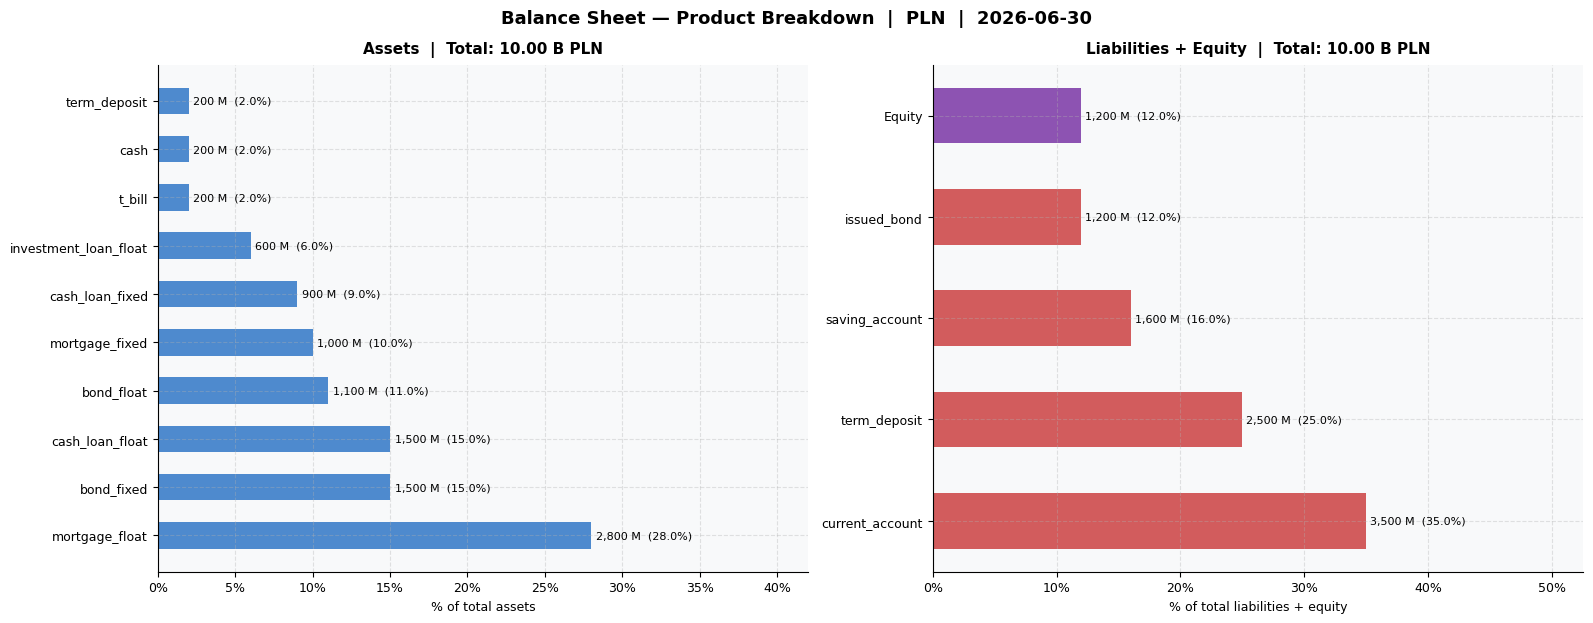

Product,Balance (M PLN),% of Assets
mortgage_float,"2,800",28.0%
bond_fixed,"1,500",15.0%
cash_loan_float,"1,500",15.0%
bond_float,"1,100",11.0%
mortgage_fixed,"1,000",10.0%
cash_loan_fixed,900,9.0%
investment_loan_float,600,6.0%
t_bill,200,2.0%
cash,200,2.0%
term_deposit,200,2.0%


Product,Balance (M PLN),% of L+E
current_account,"3,500",35.0%
term_deposit,"2,500",25.0%
saving_account,"1,600",16.0%
issued_bond,"1,200",12.0%
Equity,"1,200",12.0%
TOTAL,"10,000",100.0%


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BALANCE SHEET — PRODUCT DETAIL  (notional + % per product)
# ─────────────────────────────────────────────────────────────────────────────
pln_prod = bs_raw[bs_raw['currency'] == CCY].copy()
pln_prod_a = pln_prod[pln_prod['bs_side'] == 'A'].sort_values('balance_amt', ascending=False)
pln_prod_l = pln_prod[pln_prod['bs_side'] == 'L'].sort_values('balance_amt', ascending=False)

tot_a_p = pln_prod_a['balance_amt'].sum()
tot_l_p = pln_prod_l['balance_amt'].sum() + equity_amt

pln_prod_a = pln_prod_a.assign(pct=lambda d: d['balance_amt'] / tot_a_p * 100)
pln_prod_l = pln_prod_l.assign(pct=lambda d: d['balance_amt'] / tot_l_p * 100)
eq_pct_p   = equity_amt / tot_l_p * 100

n_a = len(pln_prod_a)
n_l = len(pln_prod_l) + 1  # +1 for equity
fig_h = max(5, max(n_a, n_l) * 0.48 + 1.5)
fig, (ax_a, ax_l) = plt.subplots(1, 2, figsize=(16, fig_h))
fig.suptitle(f'Balance Sheet — Product Breakdown  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

# ── Assets ──────────────────────────────────────────────────────────────────
y_a = np.arange(n_a)
ax_a.barh(y_a, pln_prod_a['pct'], color=C_A, alpha=0.75, height=0.55)
ax_a.set_yticks(y_a)
ax_a.set_yticklabels(pln_prod_a['product_name'].tolist(), fontsize=9)
ax_a.set_xlabel('% of total assets')
ax_a.set_title(f'Assets  |  Total: {tot_a_p/1e9:.2f} B PLN', fontsize=11, fontweight='bold')
ax_a.axvline(0, color='black', lw=0.5)
ax_a.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
for i, (_, r) in enumerate(pln_prod_a.iterrows()):
    ax_a.text(r['pct'] + 0.3, i,
              f'{r["balance_amt"]/1e6:,.0f} M  ({r["pct"]:.1f}%)',
              va='center', fontsize=8)
ax_a.set_xlim(0, pln_prod_a['pct'].max() * 1.5)

# ── Liabilities + Equity ─────────────────────────────────────────────────────
l_names  = pln_prod_l['product_name'].tolist() + ['Equity']
l_pcts   = pln_prod_l['pct'].tolist()         + [eq_pct_p]
l_bals   = pln_prod_l['balance_amt'].tolist()  + [equity_amt]
l_colors = [C_L] * len(pln_prod_l) + [C_EQ]

y_l = np.arange(len(l_names))
ax_l.barh(y_l, l_pcts, color=l_colors, alpha=0.75, height=0.55)
ax_l.set_yticks(y_l)
ax_l.set_yticklabels(l_names, fontsize=9)
ax_l.set_xlabel('% of total liabilities + equity')
ax_l.set_title(f'Liabilities + Equity  |  Total: {tot_l_p/1e9:.2f} B PLN',
               fontsize=11, fontweight='bold')
ax_l.axvline(0, color='black', lw=0.5)
ax_l.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
for i, (nm, pct_v, bal) in enumerate(zip(l_names, l_pcts, l_bals)):
    ax_l.text(pct_v + 0.3, i,
              f'{bal/1e6:,.0f} M  ({pct_v:.1f}%)',
              va='center', fontsize=8)
ax_l.set_xlim(0, max(l_pcts) * 1.5)

plt.tight_layout()
plt.show()

# ── Tables ─────────────────────────────────────────────────────────────────
_assets_rows = [[r['product_name'], f'{r["balance_amt"]/1e6:,.0f}', f'{r["pct"]:.1f}%']
                for _, r in pln_prod_a.iterrows()]
display(html_table(
    ['Product', 'Balance (M PLN)', '% of Assets'],
    _assets_rows,
    total_row=['TOTAL', f'{tot_a_p/1e6:,.0f}', '100.0%'],
    title=f'Assets  |  {CCY}  |  {REPORT_DATE.date()}',
))

_liabs_rows = [[r['product_name'], f'{r["balance_amt"]/1e6:,.0f}', f'{r["pct"]:.1f}%']
               for _, r in pln_prod_l.iterrows()]
_liabs_rows.append(['Equity', f'{equity_amt/1e6:,.0f}', f'{eq_pct_p:.1f}%'])
display(html_table(
    ['Product', 'Balance (M PLN)', '% of L+E'],
    _liabs_rows,
    total_row=['TOTAL', f'{tot_l_p/1e6:,.0f}', '100.0%'],
    title=f'Liabilities + Equity  |  {CCY}',
))

---
## 2. Market Yield Curves

Base discount / forward curves as of the report date. Decreasing discount factors or negative zero rates indicate inverted segments.

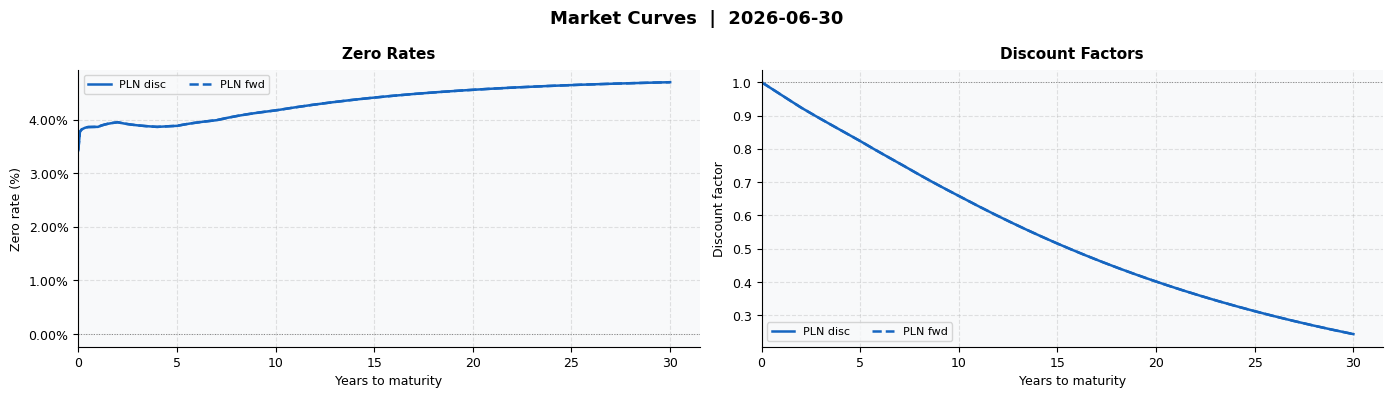

In [6]:
CURVE_STYLE = {
    'PLN_disc_curve': ('#1565C0', '-',  'PLN disc'),
    'PLN_fwd_curve':  ('#1565C0', '--', 'PLN fwd'),
    'EUR_disc_curve': ('#E65100', '-',  'EUR disc'),
    'EUR_fwd_curve':  ('#E65100', '--', 'EUR fwd'),
    'USD_disc_curve': ('#2E7D32', '-',  'USD disc'),
    'USD_fwd_curve':  ('#2E7D32', '--', 'USD fwd'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Market Curves  |  {REPORT_DATE.date()}', fontsize=13, fontweight='bold')

for curve_name, grp in mkt.groupby('curve_name'):
    grp = grp.sort_values('n_days')
    if grp['zero_rate'].isna().all(): continue
    col, ls, lbl = CURVE_STYLE.get(curve_name, (C_GR, '-', curve_name))
    x_yr = grp['n_days'] / 365.25
    ax1.plot(x_yr, grp['zero_rate'] * 100, color=col, linestyle=ls, linewidth=1.8, label=lbl)
    ax2.plot(x_yr, grp['d_f'], color=col, linestyle=ls, linewidth=1.8, label=lbl)

ax1.axhline(0, color='grey', linewidth=0.7, linestyle=':')
ax1.set_xlabel('Years to maturity')
ax1.set_ylabel('Zero rate (%)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax1.set_xlim(left=0)
ax1.set_title('Zero Rates')
ax1.legend(ncol=2)

ax2.axhline(1, color='grey', linewidth=0.7, linestyle=':')
ax2.set_xlabel('Years to maturity')
ax2.set_ylabel('Discount factor')
ax2.set_xlim(left=0)
ax2.set_title('Discount Factors')
ax2.legend(ncol=2)

plt.tight_layout()
plt.show()

---
## 2b. IRRBB Scenario Yield Curves

EBA SOT shocked zero rates applied to the PLN discount curve for the 6 supervisory scenarios (EBA/RTS/2022/10 Article 3).
The **base** curve (bold black) is the current market rate.
Shock magnitudes for PLN: parallel ±250 bps, short-rate ±350 bps, long-rate ±150 bps.


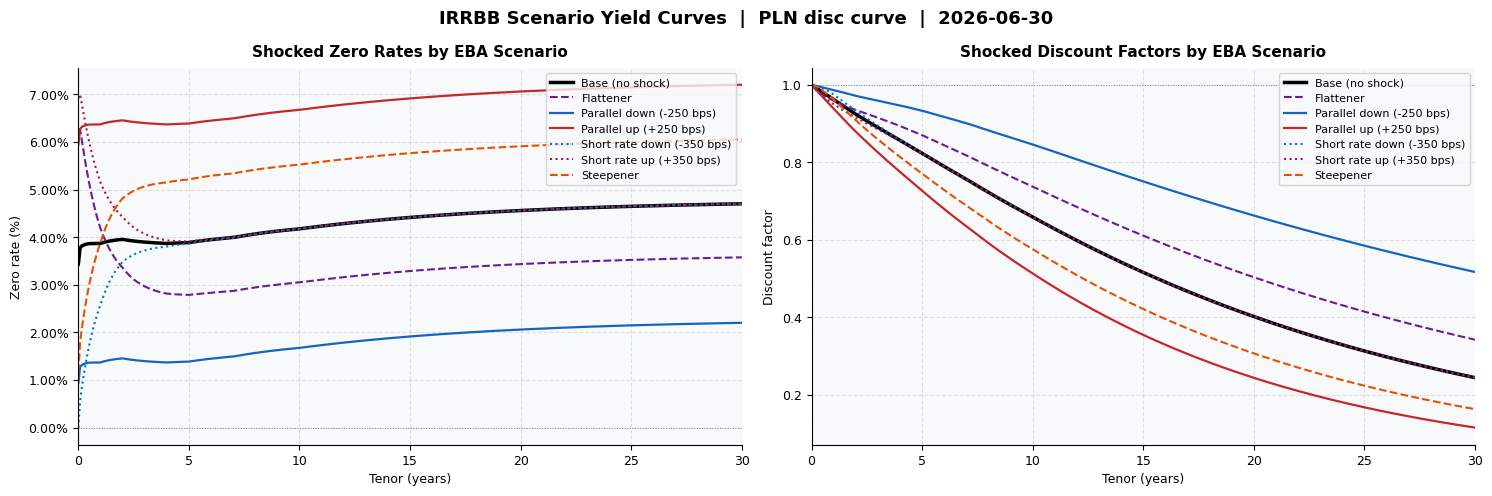

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# IRRBB SCENARIO YIELD CURVES  — base + 6 EBA SOT on PLN disc curve
# ─────────────────────────────────────────────────────────────────────────────
_SCEN_STYLE = {
    'base':   ('#000000', '-',  2.5, 'Base (no shock)'),
    'par_up': ('#C62828', '-',  1.6, 'Parallel up (+250 bps)'),
    'par_dn': ('#1565C0', '-',  1.6, 'Parallel down (-250 bps)'),
    'steep':  ('#E65100', '--', 1.5, 'Steepener'),
    'flat':   ('#6A1B9A', '--', 1.5, 'Flattener'),
    'sr_up':  ('#AD1457', ':',  1.5, 'Short rate up (+350 bps)'),
    'sr_dn':  ('#0277BD', ':',  1.5, 'Short rate down (-350 bps)'),
}

if irrbb_curves.empty:
    print('IRRBB scenario curves not available. Run nii_calc_workflow first.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'IRRBB Scenario Yield Curves  |  PLN disc curve  |  {REPORT_DATE.date()}',
                 fontsize=13, fontweight='bold')

    _max_yr = irrbb_curves['n_days'].max() / 365.25

    for sid, grp in irrbb_curves.groupby('scenario_id'):
        grp = grp.sort_values('n_days')
        col, ls, lw, lbl = _SCEN_STYLE.get(sid, ('#888888', '-', 1.2, sid))
        t_yr = grp['n_days'] / 365.25
        if 'zero_rt' in grp.columns and grp['zero_rt'].notna().any():
            zr = grp['zero_rt'] * 100
        else:
            _t  = t_yr.to_numpy()
            _df = grp['d_f'].to_numpy()
            with np.errstate(divide='ignore', invalid='ignore'):
                zr = np.where(_t > 0, -np.log(np.clip(_df, 1e-12, None)) / _t * 100, 0.0)
        ax1.plot(t_yr, zr,           color=col, ls=ls, lw=lw, label=lbl)
        ax2.plot(t_yr, grp['d_f'],   color=col, ls=ls, lw=lw, label=lbl)

    ax1.axhline(0, color='grey', lw=0.7, ls=':')
    ax1.set_xlabel('Tenor (years)'); ax1.set_ylabel('Zero rate (%)')
    ax1.set_title('Shocked Zero Rates by EBA Scenario')
    ax1.set_xlim(0, _max_yr)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
    ax1.legend(fontsize=8, loc='upper right')

    ax2.axhline(1, color='grey', lw=0.7, ls=':')
    ax2.set_xlabel('Tenor (years)'); ax2.set_ylabel('Discount factor')
    ax2.set_title('Shocked Discount Factors by EBA Scenario')
    ax2.set_xlim(0, _max_yr)
    ax2.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()


---
## 3. Interest Rate Repricing Gap

Net repricing gap = Σ asset CFs − Σ liability CFs falling in each tenor bucket.  
A **positive gap** means more assets reprice than liabilities → NII benefits from rising rates.  
A **negative gap** (liability-sensitive) → NII benefits from falling rates.  
`gap_cf_irs` = IRS contribution (from ir_derivatives workflow).

### 3a. IR Gap by Product Group

Stacked repricing gap by broad product category (assets above zero, liabilities below zero), using the same tenor grouping as the IRS view. Isolates the contribution of each product segment to the bank's interest rate exposure.

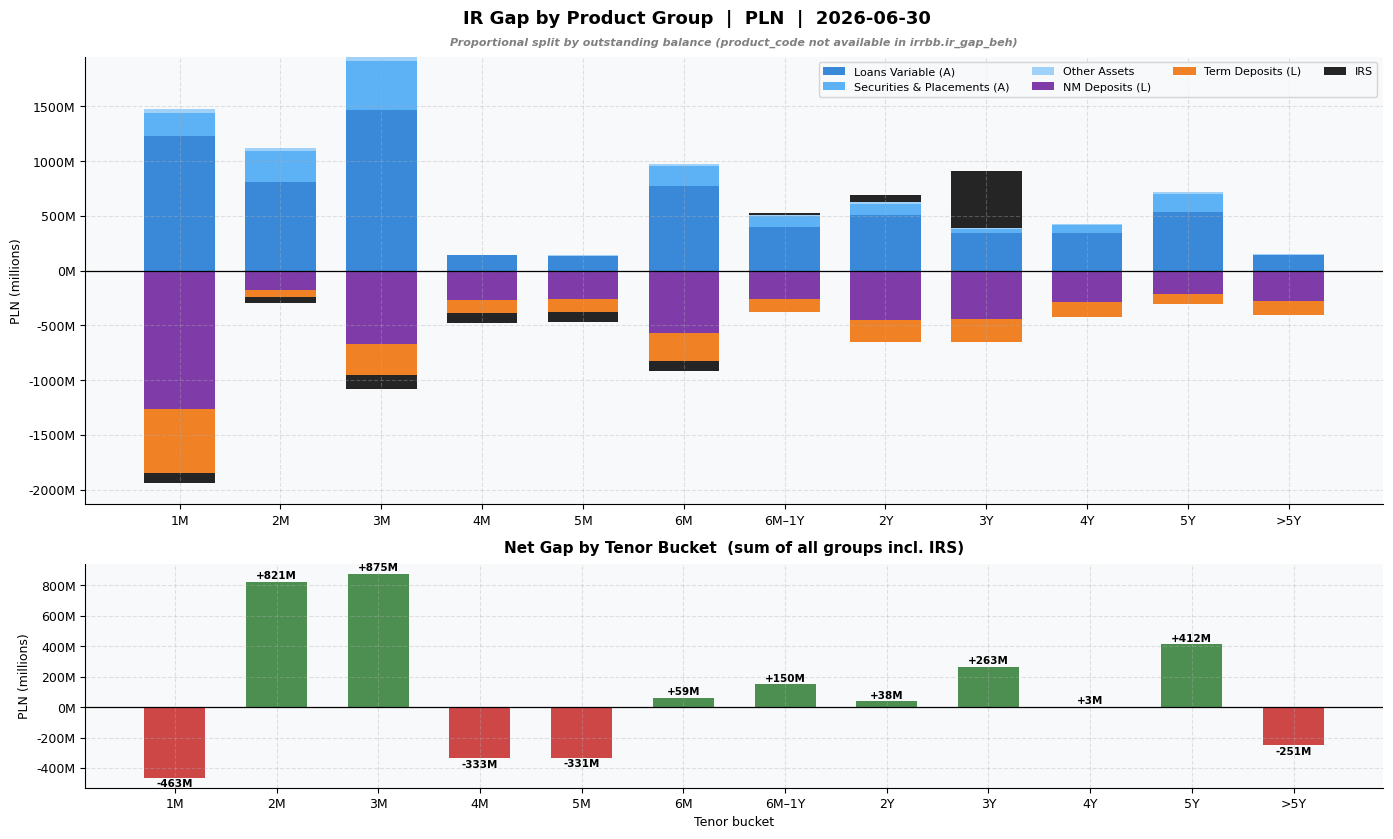

In [8]:
# -------------------------------------------------------------------
# IR GAP BY PRODUCT GROUP
# Groups by product_code from irrbb.ir_gap_beh joined to
# dbo.transactions for product_name + rate_type.
# Fallback: proportional allocation via outstanding_bal.
# -------------------------------------------------------------------

def _tgrp(tb):
    m = tkey(tb)
    if m <=  1:  return '1M'
    if m <=  2:  return '2M'
    if m <=  3:  return '3M'
    if m <=  4:  return '4M'
    if m <=  5:  return '5M'
    if m <=  6:  return '6M'
    if m <= 12:  return '6M–1Y'
    if m <= 24:  return '2Y'
    if m <= 36:  return '3Y'
    if m <= 48:  return '4Y'
    if m <= 60:  return '5Y'
    return '>5Y'

TGRP_ORDER = ['1M','2M','3M','4M','5M','6M','6M–1Y',
              '2Y','3Y','4Y','5Y','>5Y']

GRP_DEF = [
    ('Loans Fixed (A)',             '#0D47A1'),
    ('Loans Variable (A)',          '#1976D2'),
    ('Securities & Placements (A)', '#42A5F5'),
    ('Other Assets',                '#90CAF9'),
    ('NM Deposits (L)',             '#6A1B9A'),
    ('Term Deposits (L)',           '#EF6C00'),
    ('Other Liabilities',           '#FFCDD2'),
    ('IRS',                         '#000000'),
]
grp_clrs = {g: c for g, c in GRP_DEF}

def _pg(pn, bs, rt='V'):
    """Map product_name + bs_side + rate_type to display group."""
    pn = str(pn).lower();  bs = str(bs).upper();  rt = str(rt).upper()
    if any(k in pn for k in ('loan','mortgage','overdraft','leasing','credit')):
        return 'Loans Fixed (A)' if rt == 'F' else 'Loans Variable (A)'
    if any(k in pn for k in ('bond','security','tbill','treasury',
                              'placement','nostro','cash','interbank','cbm')):
        return 'Securities & Placements (A)'
    if any(k in pn for k in ('current_account','saving','saving_account','demand')):
        return 'NM Deposits (L)'
    if any(k in pn for k in ('deposit','term','account')):
        return 'Term Deposits (L)'
    return 'Other Assets' if bs == 'A' else 'Other Liabilities'

pivot    = None
_src_lbl = ''

# ── Attempt 1: product_code in ir_gap_beh joined to dbo.transactions ────────
# Join gives product_name and rate_type per product_code so Fixed/Float
# loan split is exact, not proportional.
try:
    _raw = rsql('''
        SELECT g.currency,
               g.bs_side,
               g.product_code,
               ISNULL(t.product_name, CAST(g.product_code AS NVARCHAR)) AS product_name,
               ISNULL(t.rate_type,    'V')                               AS rate_type,
               g.tenor_bucket,
               SUM(g.gap_cf)                AS gap_cf,
               SUM(ISNULL(g.gap_cf_irs,0))  AS gap_cf_irs
        FROM irrbb.ir_gap_beh g
        LEFT JOIN (
            SELECT product_code,
                   MAX(product_name)            AS product_name,
                   MAX(ISNULL(rate_type, 'V'))  AS rate_type
            FROM dbo.transactions
            WHERE report_date = :rd
            GROUP BY product_code
        ) t ON g.product_code = t.product_code
        GROUP BY g.currency, g.bs_side, g.product_code,
                 t.product_name, t.rate_type, g.tenor_bucket
    ''', rd=RD)
    _g2 = _raw[_raw['currency'] == CCY].copy()
    _g2['prod_grp'] = _g2.apply(
        lambda r: _pg(r['product_name'], r['bs_side'], r['rate_type']), axis=1)
    _g2['tgrp'] = _g2['tenor_bucket'].map(_tgrp)
    # IRS contribution as separate group
    _irs = _g2[_g2['gap_cf_irs'] != 0][['tgrp','gap_cf_irs']].copy()
    _irs.columns    = ['tgrp','gap_cf']
    _irs['prod_grp'] = 'IRS'
    _comb = pd.concat([_g2[['tgrp','prod_grp','gap_cf']], _irs],
                      ignore_index=True)
    pivot = (_comb.groupby(['tgrp','prod_grp'])['gap_cf']
             .sum().unstack(fill_value=0))
    pivot = pivot.reindex([t for t in TGRP_ORDER if t in pivot.index])
    _src_lbl = ''
except Exception as _e:
    pivot = None

# ── Attempt 2: proportional allocation from outstanding_bal ─────────────────
# Used when ir_gap_beh does not expose product_code.
# Loan F/V split uses loan_rt balance weights (already in memory).
if pivot is None:
    _obs = outstanding_bal[outstanding_bal['currency'] == CCY].copy()
    _obs['prod_grp'] = _obs.apply(
        lambda r: _pg(r.get('product_name',''), r.get('bs_side','')), axis=1)
    # Re-split generic 'Loans (A)' into Fixed/Variable using loan_rt weights
    _lr   = loan_rt[loan_rt['currency'] == CCY].set_index('rate_type')['balance_amt']
    _ltot = max(_lr.sum(), 1)
    _fw   = float(_lr.get('F', 0)) / _ltot
    _vw   = float(_lr.get('V', 0)) / _ltot
    if _fw + _vw == 0: _fw, _vw = 0.5, 0.5

    _obs_exp = []
    for _, row in _obs.iterrows():
        if row['prod_grp'] in ('Loans Fixed (A)', 'Loans Variable (A)'):
            # Already split correctly via rate_type in _pg if available
            _obs_exp.append({'prod_grp': row['prod_grp'],
                             'bs_side':  row['bs_side'],
                             'balance_amt': row['balance_amt']})
        else:
            _obs_exp.append({'prod_grp': row['prod_grp'],
                             'bs_side':  row['bs_side'],
                             'balance_amt': row['balance_amt']})
    _obs2 = pd.DataFrame(_obs_exp)
    _obs_a = _obs2[_obs2['bs_side']=='A'].groupby('prod_grp')['balance_amt'].sum()
    _obs_l = _obs2[_obs2['bs_side']=='L'].groupby('prod_grp')['balance_amt'].sum()

    # Split any remaining 'Loans (A)' bucket (catch-all from _pg)
    def _expand_loans(s, fw, vw):
        if 'Loans (A)' in s.index:
            v = s.pop('Loans (A)')
            s['Loans Fixed (A)']    = s.get('Loans Fixed (A)', 0)    + v * fw
            s['Loans Variable (A)'] = s.get('Loans Variable (A)', 0) + v * vw
        return s
    _obs_a = _expand_loans(_obs_a.copy(), _fw, _vw)

    _a_tot = max(_obs_a.sum(), 1)
    _l_tot = max(_obs_l.sum(), 1)

    _g = ir_gap[ir_gap['currency'] == CCY].copy()
    _g['tgrp'] = _g['tenor_bucket'].map(_tgrp)
    _gap_bs = _g.groupby(['bs_side','tgrp'])[['gap_cf','gap_cf_irs']].sum()

    _rows = []
    for (_bs, _tg), _row in _gap_bs.iterrows():
        _gap, _irs_cf = _row['gap_cf'], _row['gap_cf_irs']
        _side = _obs_a if _bs == 'A' else _obs_l
        _tot  = _a_tot  if _bs == 'A' else _l_tot
        if _side.empty:
            _rows.append({'tgrp': _tg,
                          'prod_grp': 'Other Assets' if _bs=='A' else 'Other Liabilities',
                          'gap_cf': _gap})
        else:
            for _pg_name, _bal in _side.items():
                _rows.append({'tgrp': _tg, 'prod_grp': _pg_name,
                              'gap_cf': _gap * _bal / _tot})
        if _irs_cf != 0:
            _rows.append({'tgrp': _tg, 'prod_grp': 'IRS', 'gap_cf': _irs_cf})

    if _rows:
        _df  = pd.DataFrame(_rows)
        pivot = (_df.groupby(['tgrp','prod_grp'])['gap_cf']
                 .sum().unstack(fill_value=0))
        pivot = pivot.reindex([t for t in TGRP_ORDER if t in pivot.index])
    _src_lbl = (
        'Proportional split by outstanding balance '
        '(product_code not available in irrbb.ir_gap_beh)'
    )

# ── Plot ────────────────────────────────────────────────────────────────────
if pivot is not None and not pivot.empty:
    grp_names = [g for g, _ in GRP_DEF if g in pivot.columns]
    x_p = np.arange(len(pivot))

    fig, (ax, ax_net) = plt.subplots(2, 1, figsize=(14, 8.5),
                                      gridspec_kw={'height_ratios': [2, 1]})
    _title = f'IR Gap by Product Group  |  {CCY}  |  {REPORT_DATE.date()}'
    fig.suptitle(_title, fontsize=13, fontweight='bold')
    if _src_lbl:
        ax.set_title(_src_lbl, fontsize=8, color='grey', style='italic')

    pos_bot    = np.zeros(len(pivot))
    neg_bot    = np.zeros(len(pivot))
    _in_legend = set()
    for grp in grp_names:
        if grp not in pivot.columns:
            continue
        vals  = pivot[grp].values / 1e6
        pos_v = np.where(vals >= 0, vals, 0)
        neg_v = np.where(vals <  0, vals, 0)
        clr   = grp_clrs[grp]
        lbl   = grp if grp not in _in_legend else '_nolegend_'
        if pos_v.any():
            ax.bar(x_p, pos_v, bottom=pos_bot, color=clr, alpha=0.85,
                   width=0.7, label=lbl)
            pos_bot += pos_v;  _in_legend.add(grp);  lbl = '_nolegend_'
        if neg_v.any():
            ax.bar(x_p, neg_v, bottom=neg_bot, color=clr, alpha=0.85,
                   width=0.7, label=lbl)
            neg_bot += neg_v;  _in_legend.add(grp)

    ax.axhline(0, color='black', lw=0.9)
    ax.set_xticks(x_p)
    ax.set_xticklabels(pivot.index, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax.set_ylabel('PLN (millions)')
    ax.legend(ncol=4, fontsize=8, loc='upper right')

    # ── Net gap (sum across all groups incl. IRS) per tenor bucket ────────────
    net_gap = pivot[grp_names].sum(axis=1) / 1e6
    net_colors = [C_N if v >= 0 else C_L for v in net_gap]
    ax_net.bar(x_p, net_gap, color=net_colors, alpha=0.85, width=0.6)
    for i, v in enumerate(net_gap):
        ax_net.text(i, v + (8 if v >= 0 else -8), f'{v:+.0f}M',
                    ha='center', va='bottom' if v >= 0 else 'top',
                    fontsize=7.5, fontweight='bold')
    ax_net.axhline(0, color='black', lw=0.9)
    ax_net.set_xticks(x_p)
    ax_net.set_xticklabels(pivot.index, fontsize=9)
    ax_net.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax_net.set_ylabel('PLN (millions)')
    ax_net.set_xlabel('Tenor bucket')
    ax_net.set_title('Net Gap by Tenor Bucket  (sum of all groups incl. IRS)')

    plt.tight_layout()
    plt.show()
else:
    print('  No data available for IR Gap by Product Group.')

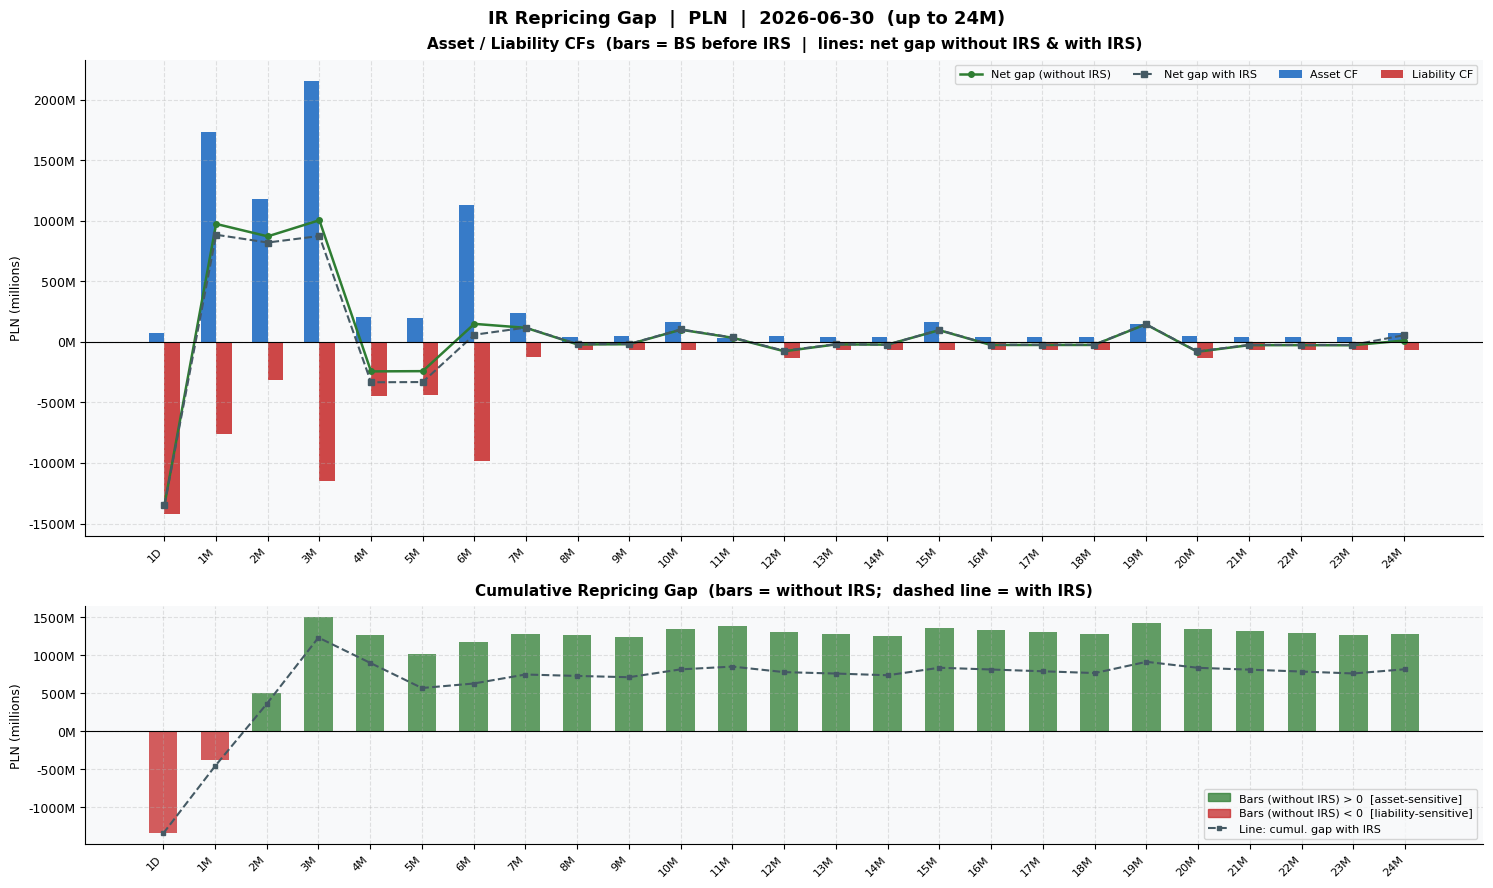

Bucket,Asset CF (M),Liab CF (M),Net BS (M),IRS (M),Net+IRS (M),Cum Net (M)
1D,75,"-1,423","-1,348",0,"-1,348","-1,348"
1M,"1,735",-761,975,-90,885,-373
2M,"1,183",-311,872,-51,821,499
3M,"2,153","-1,148","1,005",-130,875,"1,504"
4M,207,-450,-243,-90,-333,"1,260"
5M,199,-440,-241,-90,-331,"1,019"
6M,"1,133",-983,149,-90,59,"1,168"
7M,241,-124,116,2,119,"1,285"
8M,44,-65,-21,2,-19,"1,264"
9M,46,-65,-19,2,-17,"1,245"


In [9]:
g = ir_gap[ir_gap['currency'] == CCY].copy()

# Net gap (signed: A=+, L=-) and IRS
net_bs  = g.groupby('tenor_bucket')[['gap_cf', 'gap_cf_irs']].sum().reset_index()
net_bs['net_total'] = net_bs['gap_cf'] + net_bs['gap_cf_irs']

# Separate asset and liability for waterfall bars
a_gap = (g[g['bs_side'] == 'A'].groupby('tenor_bucket')['gap_cf']
         .sum().rename('asset_cf').reset_index())
l_gap = (g[g['bs_side'] == 'L'].groupby('tenor_bucket')['gap_cf']
         .sum().rename('liab_cf').reset_index())

gap_df = (net_bs
          .merge(a_gap, on='tenor_bucket', how='outer')
          .merge(l_gap, on='tenor_bucket', how='outer')
          .fillna(0.0))
gap_df = sbkt(gap_df)
gap_df['cum_net']   = gap_df['gap_cf'].cumsum()
gap_df['cum_total'] = gap_df['net_total'].cumsum()

# Limit detail display to <=24M
MAX_M = 24
gp = gap_df[gap_df['tenor_bucket'].map(tkey) <= MAX_M].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'IR Repricing Gap  |  {CCY}  |  {REPORT_DATE.date()}  (up to 24M)',
             fontsize=13, fontweight='bold')

labels = gp['tenor_bucket'].tolist()
x = np.arange(len(labels))
w = 0.3

# Upper: asset / liability / net
ax1.bar(x - w/2, gp['asset_cf']/1e6, w, label='Asset CF',     color=C_A, alpha=0.85)
ax1.bar(x + w/2, gp['liab_cf']/1e6,  w, label='Liability CF', color=C_L, alpha=0.85)
ax1.plot(x, gp['gap_cf']/1e6,    color=C_N,  marker='o', ms=4, lw=1.8, label='Net gap (without IRS)')
ax1.plot(x, gp['net_total']/1e6, color=C_GR, marker='s', ms=4, lw=1.5,
         linestyle='--', label='Net gap with IRS')
ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax1.set_ylabel('PLN (millions)')
ax1.set_title('Asset / Liability CFs  '
              '(bars = BS before IRS  |  lines: net gap without IRS & with IRS)')
ax1.legend(ncol=4)

# Lower: cumulative gap
bar_colors = [C_N if v >= 0 else C_L for v in gp['cum_net']]
ax2.bar(x, gp['cum_net']/1e6,   color=bar_colors, alpha=0.75, width=0.55)
ax2.plot(x, gp['cum_total']/1e6, color=C_GR, lw=1.5, linestyle='--',
         marker='s', ms=3, label='Cumul. net with IRS')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax2.set_ylabel('PLN (millions)')
ax2.set_title('Cumulative Repricing Gap  '
              '(bars = without IRS;  dashed line = with IRS)')
# Explicit legend for colour coding
_p_pos = mpatches.Patch(color=C_N, alpha=0.75,
                         label='Bars (without IRS) > 0  [asset-sensitive]')
_p_neg = mpatches.Patch(color=C_L, alpha=0.75,
                         label='Bars (without IRS) < 0  [liability-sensitive]')
_p_irs = plt.Line2D([0],[0], color=C_GR, lw=1.5, linestyle='--',
                    marker='s', ms=3, label='Line: cumul. gap with IRS')
ax2.legend(handles=[_p_pos, _p_neg, _p_irs], fontsize=8)

plt.tight_layout()
plt.show()

# -- Table -----------------------------------------------------------------------
_gap_rows = [
    [r['tenor_bucket'], f'{r["asset_cf"]/1e6:,.0f}', f'{r["liab_cf"]/1e6:,.0f}',
     pos_neg(r['gap_cf']/1e6, ',.0f'), f'{r["gap_cf_irs"]/1e6:,.0f}',
     pos_neg(r['net_total']/1e6, ',.0f'), f'{r["cum_net"]/1e6:,.0f}']
    for _, r in gp.iterrows()
]

# Totals beyond 24M
beyond = gap_df[gap_df['tenor_bucket'].map(tkey) > MAX_M]
if not beyond.empty:
    _gap_rows.append(['>24M', f'{beyond["asset_cf"].sum()/1e6:,.0f}',
                       f'{beyond["liab_cf"].sum()/1e6:,.0f}',
                       pos_neg(beyond['gap_cf'].sum()/1e6, ',.0f'), '', '', ''])

display(html_table(
    ['Bucket', 'Asset CF (M)', 'Liab CF (M)', 'Net BS (M)', 'IRS (M)', 'Net+IRS (M)', 'Cum Net (M)'],
    _gap_rows,
    total_row=['TOTAL', f'{gap_df["asset_cf"].sum()/1e6:,.0f}', f'{gap_df["liab_cf"].sum()/1e6:,.0f}',
               pos_neg(gap_df['gap_cf'].sum()/1e6, ',.0f'), f'{gap_df["gap_cf_irs"].sum()/1e6:,.0f}',
               pos_neg(gap_df['net_total'].sum()/1e6, ',.0f'), ''],
))

### 3b. IRS Book Repricing Profile

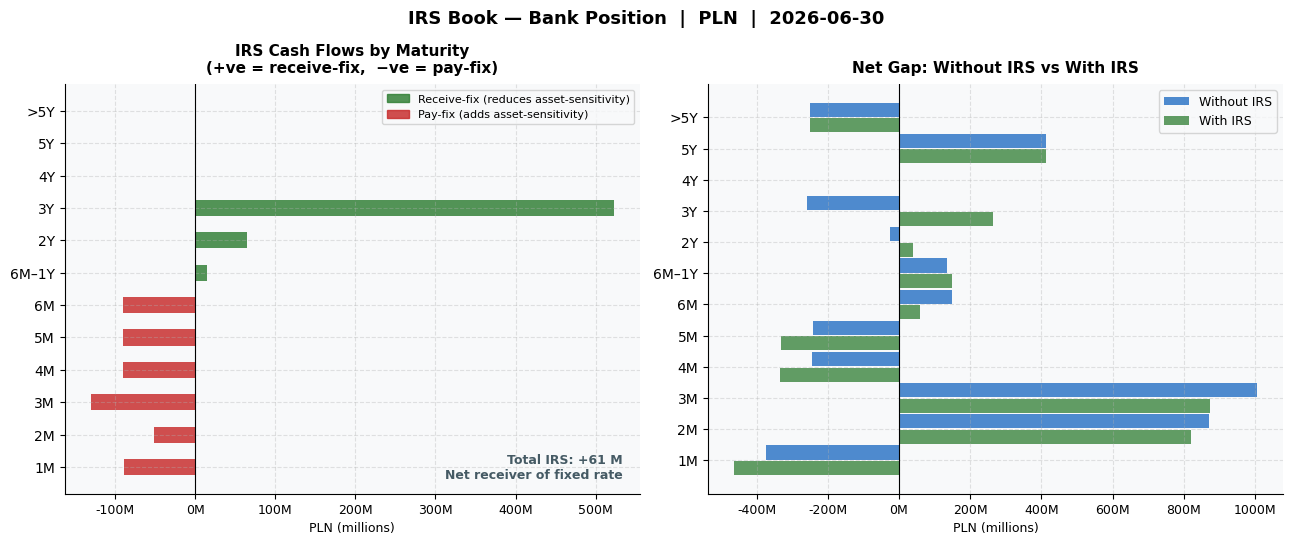

BS (before IRS): asset-sensitive  ->  After IRS: asset-sensitive


In [10]:
# -------------------------------------------------------------------
# IRS BOOK POSITION  -- monthly up to 6M, then 6M-1Y, then annual to 5Y
# -------------------------------------------------------------------
g_irs = ir_gap[ir_gap['currency'] == CCY].copy()
irs_df = (g_irs.groupby('tenor_bucket')[['gap_cf', 'gap_cf_irs']]
          .sum().reset_index())
irs_df['net_total'] = irs_df['gap_cf'] + irs_df['gap_cf_irs']
irs_df = sbkt(irs_df)

# Group into fine monthly buckets up to 6M, then 6M-1Y, then annual
def _irs_grp(tb):
    m = tkey(tb)
    if m <=  1:  return '1M'
    if m <=  2:  return '2M'
    if m <=  3:  return '3M'
    if m <=  4:  return '4M'
    if m <=  5:  return '5M'
    if m <=  6:  return '6M'
    if m <= 12:  return '6M–1Y'
    if m <= 24:  return '2Y'
    if m <= 36:  return '3Y'
    if m <= 48:  return '4Y'
    if m <= 60:  return '5Y'
    return '>5Y'

irs_df['grp'] = irs_df['tenor_bucket'].map(_irs_grp)
GRP_ORDER = ['1M', '2M', '3M', '4M', '5M', '6M', '6M–1Y',
             '2Y', '3Y', '4Y', '5Y', '>5Y']
irs_grp = (irs_df.groupby('grp')[['gap_cf', 'gap_cf_irs', 'net_total']]
           .sum().reindex([g for g in GRP_ORDER if g in irs_df['grp'].unique()]))

fig, (axI1, axI2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(f'IRS Book — Bank Position  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

y_g = np.arange(len(irs_grp))
h   = 0.5

# Left: IRS CFs by grouped maturity -- horizontal bars
irs_clrs = [C_N if v >= 0 else C_L for v in irs_grp['gap_cf_irs']]
axI1.barh(y_g, irs_grp['gap_cf_irs'] / 1e6, height=h, color=irs_clrs, alpha=0.82)
axI1.axvline(0, color='black', lw=0.8)
axI1.set_yticks(y_g)
axI1.set_yticklabels(irs_grp.index, fontsize=10)
axI1.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
axI1.set_xlabel('PLN (millions)')
axI1.set_title('IRS Cash Flows by Maturity\n(+ve = receive-fix,  −ve = pay-fix)')
_p_rec = mpatches.Patch(color=C_N, alpha=0.82, label='Receive-fix (reduces asset-sensitivity)')
_p_pay = mpatches.Patch(color=C_L, alpha=0.82, label='Pay-fix (adds asset-sensitivity)')
axI1.legend(handles=[_p_rec, _p_pay], fontsize=8)
total_irs = irs_grp['gap_cf_irs'].sum()
direction = 'Net receiver of fixed rate' if total_irs >= 0 else 'Net payer of fixed rate'
axI1.text(0.97, 0.03, f'Total IRS: {total_irs/1e6:+,.0f} M\n{direction}',
          transform=axI1.transAxes, ha='right', va='bottom',
          fontsize=9, fontweight='bold', color=C_GR)

# Right: Gap without IRS vs with IRS -- paired horizontal bars
axI2.barh(y_g + h/2, irs_grp['gap_cf'] / 1e6,    h * 0.9,
          label='Without IRS', color=C_A, alpha=0.75)
axI2.barh(y_g - h/2, irs_grp['net_total'] / 1e6,  h * 0.9,
          label='With IRS',    color=C_N, alpha=0.75)
axI2.axvline(0, color='black', lw=0.8)
axI2.set_yticks(y_g)
axI2.set_yticklabels(irs_grp.index, fontsize=10)
axI2.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
axI2.set_xlabel('PLN (millions)')
axI2.set_title('Net Gap: Without IRS vs With IRS')
axI2.legend(fontsize=9)

plt.tight_layout()
plt.show()

bs_sens  = "asset-sensitive" if irs_df["gap_cf"].sum() > 0 else "liability-sensitive"
net_sens = "asset-sensitive" if irs_df["net_total"].sum() > 0 else "liability-sensitive"
print(f'BS (before IRS): {bs_sens}  ->  After IRS: {net_sens}')

---
## 4. Liquidity Gap

Behavioural liquidity gap: asset CFs (inflows, +) vs liability CFs (outflows, −) placed at each tenor bucket.  
Cumulative gap below zero indicates a funding shortfall at that horizon.

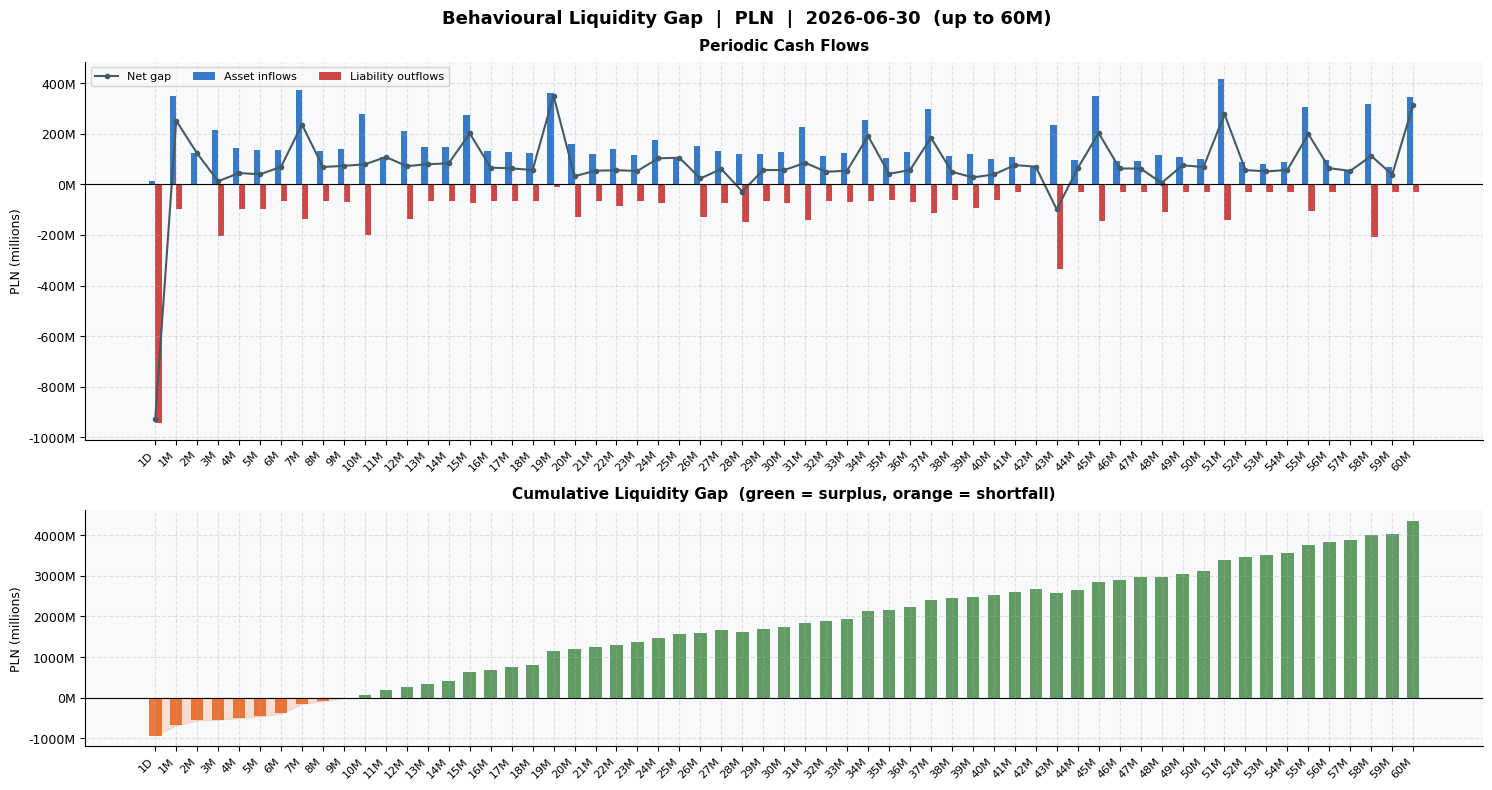


  Max surplus : 60M  →  +4,352 M PLN
  Max shortfall: 1D  →  -930 M PLN


In [11]:
lg = liq_gap[liq_gap['currency'] == CCY].copy()
net_liq = lg.groupby('tenor_bucket')['gap_cf'].sum().reset_index()
net_liq = sbkt(net_liq)
net_liq['cum'] = net_liq['gap_cf'].cumsum()

# Asset and liability separately
la_liq = (lg[lg['bs_side'] == 'A'].groupby('tenor_bucket')['gap_cf']
          .sum().rename('asset_cf').reset_index())
ll_liq = (lg[lg['bs_side'] == 'L'].groupby('tenor_bucket')['gap_cf']
          .sum().rename('liab_cf').reset_index())
liq_df = (net_liq
          .merge(la_liq, on='tenor_bucket', how='left')
          .merge(ll_liq, on='tenor_bucket', how='left')
          .fillna(0.0))

MAX_M_LIQ = 60
lp = liq_df[liq_df['tenor_bucket'].map(tkey) <= MAX_M_LIQ].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8),
                                gridspec_kw={'height_ratios': [1.6, 1]})
fig.suptitle(f'Behavioural Liquidity Gap  |  {CCY}  |  {REPORT_DATE.date()}  (up to 60M)',
             fontsize=13, fontweight='bold')

labels_l = lp['tenor_bucket'].tolist()
x_l = np.arange(len(labels_l))
w_l = 0.3

ax1.bar(x_l - w_l/2, lp['asset_cf']/1e6, w_l, label='Asset inflows',    color=C_A, alpha=0.85)
ax1.bar(x_l + w_l/2, lp['liab_cf']/1e6,  w_l, label='Liability outflows',color=C_L, alpha=0.85)
bar_col_n = [C_N if v >= 0 else C_L for v in lp['gap_cf']]
ax1.plot(x_l, lp['gap_cf']/1e6, color=C_GR, marker='o', ms=3, lw=1.5, label='Net gap')
ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(x_l)
ax1.set_xticklabels(labels_l, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax1.set_ylabel('PLN (millions)')
ax1.set_title('Periodic Cash Flows')
ax1.legend(ncol=3)

cum_col = [C_OK if v >= 0 else C_WN for v in lp['cum']]
ax2.bar(x_l, lp['cum']/1e6, color=cum_col, alpha=0.75, width=0.6)
ax2.fill_between(x_l, lp['cum']/1e6, 0, where=(lp['cum'] < 0), alpha=0.15, color=C_WN)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x_l)
ax2.set_xticklabels(labels_l, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax2.set_ylabel('PLN (millions)')
ax2.set_title('Cumulative Liquidity Gap  (green = surplus, orange = shortfall)')

plt.tight_layout()
plt.show()

# Highlight largest shortfall
min_row = lp.loc[lp['cum'].idxmin()]
max_row = lp.loc[lp['cum'].idxmax()]
print(f'\n  Max surplus : {max_row["tenor_bucket"]}  →  {max_row["cum"]/1e6:+,.0f} M PLN')
print(f'  Max shortfall: {min_row["tenor_bucket"]}  →  {min_row["cum"]/1e6:+,.0f} M PLN')

---
## 5. Behavioural Run-off

Compares how fast the balance sheet runs off under **contractual** terms vs **behavioural** assumptions (prepayments for loans; replication / early withdrawal for deposits).  
Behavioural models shift deposit maturities outward (replication) and accelerate loan repayments (prepayments).

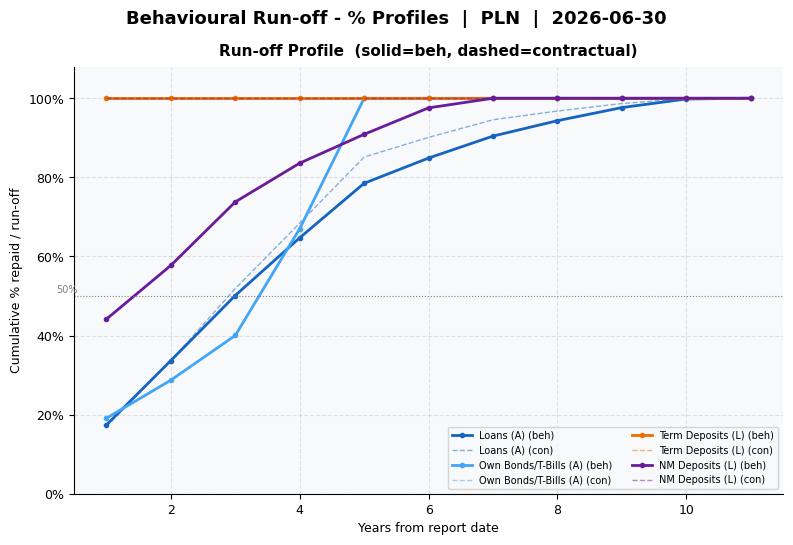

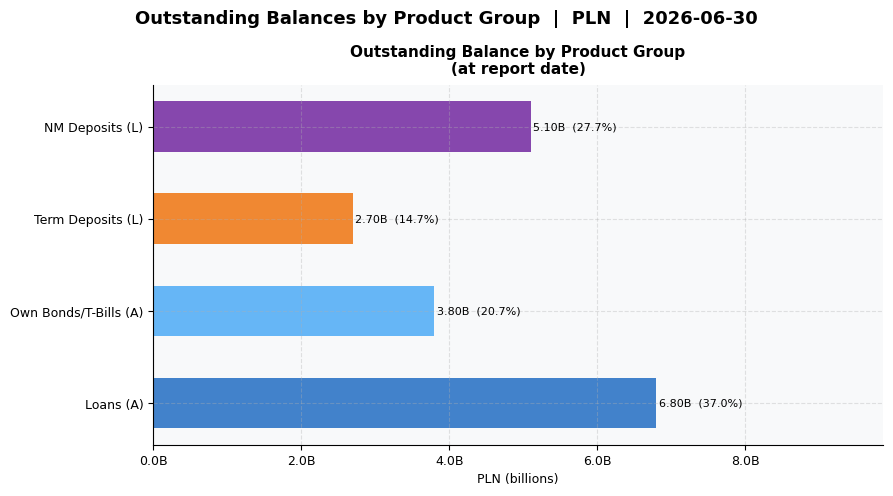

Subgroup,Balance (M PLN),% of total
Loans (A),"6,800",37.0%
Own Bonds/T-Bills (A),"3,800",20.7%
Term Deposits (L),"2,700",14.7%
NM Deposits (L),"5,100",27.7%
TOTAL,"18,400",100.0%


In [12]:
# -------------------------------------------------------------------
# BEHAVIOURAL RUN-OFF -- % profiles + outstanding notional
# Split: NM deposits vs term deposits  |  loans vs securities
# -------------------------------------------------------------------
ro = runoff[runoff['currency'] == CCY].copy()
ro['yf'] = (ro['cf_end_dt'] - REPORT_DATE).dt.days / 365.25
ro['yr'] = np.ceil(ro['yf']).clip(1, 30).astype(int)


def _subgroup(row):
    pt = str(row.get('product_type', '')).upper()
    pn = str(row.get('product_name', '')).lower()
    if any(k in pn for k in ('current_account', 'saving', 'saving_account', 'demand')):
        return 'NM Deposits (L)'
    if pt == 'D' or 'deposit' in pn or 'account' in pn:
        return 'Term Deposits (L)'
    if pt == 'L' or any(k in pn for k in ('loan', 'mortgage', 'overdraft', 'leasing')):
        return 'Loans (A)'
    if pt == 'F' or any(k in pn for k in ('bond', 'security', 'tbill', 'treasury')):
        return 'Own Bonds/T-Bills (A)'
    if pt == 'S' or 'swap' in pn:
        return 'Swaps'
    PTYPE = {'L': 'Loans (A)', 'D': 'Term Deposits (L)',
             'F': 'Own Bonds/T-Bills (A)', 'S': 'Swaps'}
    return PTYPE.get(pt, 'Other')


ro['subgroup'] = ro.apply(_subgroup, axis=1)

# -- Outstanding balances by subgroup ----------------------------------------
def _sg_bs(row):
    pn = str(row.get('product_name', '')).lower()
    if any(k in pn for k in ('current_account', 'saving', 'saving_account', 'demand')):
        return 'NM Deposits (L)'
    if 'deposit' in pn or ('account' in pn and 'current' not in pn and 'saving' not in pn):
        return 'Term Deposits (L)'
    if any(k in pn for k in ('loan', 'mortgage', 'overdraft', 'leasing')):
        return 'Loans (A)'
    if any(k in pn for k in ('bond', 'security', 'tbill', 'treasury')):
        return 'Own Bonds/T-Bills (A)'
    return 'Other'

if not outstanding_bal.empty:
    obs = outstanding_bal[outstanding_bal['currency'] == CCY].copy()
    obs['subgroup'] = obs.apply(_subgroup, axis=1)
    outstanding_by_sg = obs.groupby('subgroup')['balance_amt'].sum()
else:
    obs = bs_raw[bs_raw['currency'] == CCY].copy()
    obs['subgroup'] = obs.apply(_sg_bs, axis=1)
    outstanding_by_sg = obs.groupby('subgroup')['balance_amt'].sum()

# -- Build cumulative run-off -------------------------------------------------
cumul = (ro.groupby(['subgroup', 'yr'])[['beh_cap', 'con_cap']]
         .sum().reset_index().sort_values(['subgroup', 'yr']))
cumul['beh_cum'] = cumul.groupby('subgroup')['beh_cap'].cumsum()
cumul['con_cum'] = cumul.groupby('subgroup')['con_cap'].cumsum()
totals_b = cumul.groupby('subgroup')['beh_cap'].sum()
totals_c = cumul.groupby('subgroup')['con_cap'].sum()
for sg in cumul['subgroup'].unique():
    m  = cumul['subgroup'] == sg
    tb = max(totals_b.get(sg, 0), 1)
    tc = max(totals_c.get(sg, 0), 1)
    cumul.loc[m, 'beh_pct'] = cumul.loc[m, 'beh_cum'] / tb * 100
    cumul.loc[m, 'con_pct'] = cumul.loc[m, 'con_cum'] / tc * 100

# Distinct colors: assets=blue family, NM deposits=purple, term deposits=orange
SUBGROUP_COLOR = {
    'Loans (A)':        C_A,          # dark blue
    'Own Bonds/T-Bills (A)':   '#42A5F5',    # light blue
    'NM Deposits (L)':  '#6A1B9A',    # purple
    'Term Deposits (L)':'#EF6C00',    # orange
    'Swaps':            C_GR,
    'Other':            '#90A4AE',
}
_SG_ORDER = ['Loans (A)', 'Own Bonds/T-Bills (A)', 'Term Deposits (L)',
             'NM Deposits (L)', 'Swaps', 'Other']
all_sgs = sorted(cumul['subgroup'].unique(),
                 key=lambda s: _SG_ORDER.index(s) if s in _SG_ORDER else 99)

YR_MAX = int(min(cumul['yr'].max(), 15))
YRS    = list(range(1, YR_MAX + 1))

# -- Figure 1: % run-off profile -------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 5.5))
fig1.suptitle(f'Behavioural Run-off - % Profiles  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

for sg in all_sgs:
    grp   = cumul[cumul['subgroup'] == sg]
    color = SUBGROUP_COLOR.get(sg, C_GR)
    g2    = (grp[grp['yr'] <= YR_MAX].set_index('yr')
             .reindex(YRS).ffill().reset_index())
    ax1.plot(g2['yr'], g2['beh_pct'], color=color, lw=2,
             marker='o', ms=3, label=f'{sg} (beh)')
    ax1.plot(g2['yr'], g2['con_pct'], color=color, lw=1,
             linestyle='--', alpha=0.5, label=f'{sg} (con)')

ax1.axhline(50, color='grey', lw=0.8, linestyle=':')
ax1.text(YR_MAX * 0.02, 51, '50%', fontsize=7, color='grey')
ax1.set_xlabel('Years from report date')
ax1.set_ylabel('Cumulative % repaid / run-off')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
ax1.set_ylim(0, 108)
ax1.set_title('Run-off Profile  (solid=beh, dashed=contractual)')
ax1.legend(ncol=2, fontsize=7)

plt.tight_layout()
plt.show()

# -- Figure 2: outstanding notional by product group ------------------------
obs_order = [sg for sg in all_sgs if sg in outstanding_by_sg.index and
             outstanding_by_sg.get(sg, 0) > 0]
if obs_order:
    fig2, axO1 = plt.subplots(figsize=(9, 5))
    fig2.suptitle(
        f'Outstanding Balances by Product Group  |  {CCY}  |  {REPORT_DATE.date()}',
        fontsize=13, fontweight='bold')

    obs_vals  = [outstanding_by_sg.get(sg, 0) for sg in obs_order]
    obs_clrs  = [SUBGROUP_COLOR.get(sg, C_GR)  for sg in obs_order]
    y_obs = np.arange(len(obs_order))
    axO1.barh(y_obs, [v/1e9 for v in obs_vals], color=obs_clrs, alpha=0.8, height=0.55)
    axO1.set_yticks(y_obs)
    axO1.set_yticklabels(obs_order, fontsize=9)
    axO1.xaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
    axO1.set_xlabel('PLN (billions)')
    axO1.set_title('Outstanding Balance by Product Group\n(at report date)')
    tot_obs = sum(obs_vals)
    for i, v in enumerate(obs_vals):
        axO1.text(v/1e9 + 0.03, i,
                  f'{v/1e9:.2f}B  ({v/tot_obs*100:.1f}%)',
                  va='center', fontsize=8)
    axO1.set_xlim(0, max(v/1e9 for v in obs_vals) * 1.45)

    plt.tight_layout()
    plt.show()

    # Summary table
    _obs_rows = [[sg, f'{v/1e6:,.0f}', f'{v/tot_obs*100:.1f}%']
                 for sg, v in zip(obs_order, obs_vals)]
    display(html_table(
        ['Subgroup', 'Balance (M PLN)', '% of total'],
        _obs_rows,
        total_row=['TOTAL', f'{tot_obs/1e6:,.0f}', '100.0%'],
        title=f'Outstanding Balances  |  {CCY}',
    ))


### CF-Based NII by Scenario

Full CF-based NII from `irrbb.nii_results` split by **existing-book interest** and **renewal** income.

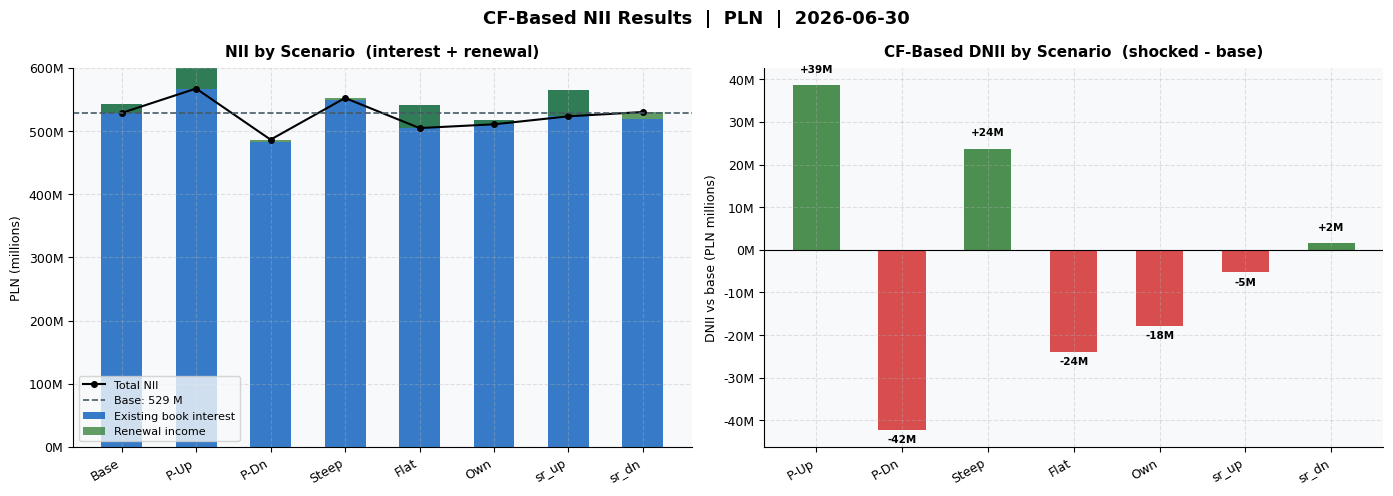

In [13]:
# ── NII base: interest vs renewal + delta by scenario ───────────────────────
nii_b = nii_scen[nii_scen['currency'] == CCY].copy()
_sid_order = ['base', 'par_up', 'par_dn', 'steep', 'flat', 'short_up', 'short_dn', 'own']
nii_b = (nii_b.assign(
            order=lambda d: d['scenario_id'].map({s: i for i, s in enumerate(_sid_order)}))
          .sort_values('order').reset_index(drop=True))
_lbl_map = {'base': 'Base', 'par_up': 'P-Up', 'par_dn': 'P-Dn',
            'steep': 'Steep', 'flat': 'Flat',
            'short_up': 'S-Up', 'short_dn': 'S-Dn', 'own': 'Own'}
nii_b['label'] = nii_b['scenario_id'].map(_lbl_map).fillna(nii_b['scenario_id'])

base_nii_val = float(nii_b.loc[nii_b['scenario_id'] == 'base', 'nii_total'].iloc[0]) \
               if 'base' in nii_b['scenario_id'].values else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'CF-Based NII Results  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

# Left: stacked bars
x2 = np.arange(len(nii_b))
ax1.bar(x2, nii_b['nii_interest'] / 1e6, 0.55,
        label='Existing book interest', color=C_A, alpha=0.85)
ax1.bar(x2, nii_b['nii_renewal']  / 1e6, 0.55,
        bottom=nii_b['nii_interest'] / 1e6,
        label='Renewal income', color=C_N, alpha=0.75)
ax1.plot(x2, nii_b['nii_total'] / 1e6, color='black', marker='o', ms=4, lw=1.5,
         label='Total NII')
ax1.axhline(base_nii_val / 1e6, color=C_GR, lw=1.2, linestyle='--',
            label=f'Base: {base_nii_val/1e6:,.0f} M')
ax1.set_xticks(x2)
ax1.set_xticklabels(nii_b['label'].tolist(), rotation=30, ha='right')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax1.set_ylabel('PLN (millions)')
ax1.set_title('NII by Scenario  (interest + renewal)')
ax1.legend()

# Right: DNII vs base
shocked_nb = nii_b[nii_b['scenario_id'] != 'base'].copy()
if not shocked_nb.empty:
    shocked_nb['delta_nii'] = shocked_nb['nii_total'] - base_nii_val
    x_s = np.arange(len(shocked_nb))
    cols_d = [C_UP if v < 0 else C_N for v in shocked_nb['delta_nii']]
    ax2.bar(x_s, shocked_nb['delta_nii'] / 1e6, color=cols_d, alpha=0.85, width=0.55)
    ax2.axhline(0, color='black', lw=0.8)
    for i, v in enumerate(shocked_nb['delta_nii']):
        offset = 3 if v >= 0 else -3
        ax2.text(i, v / 1e6 + offset, f'{v/1e6:+.0f}M',
                 ha='center', fontsize=7.5, fontweight='bold')
    ax2.set_xticks(x_s)
    ax2.set_xticklabels(shocked_nb['label'].tolist(), rotation=30, ha='right')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax2.set_ylabel('DNII vs base (PLN millions)')
    ax2.set_title('CF-Based DNII by Scenario  (shocked - base)')
else:
    ax2.text(0.5, 0.5, 'No shocked NII data', transform=ax2.transAxes,
             ha='center', va='center')
plt.tight_layout()
plt.show()


---
## 7. EBA IRRBB Supervisory Outlier Test (SOT)

**EVE SOT** — threshold: ΔEVE / Tier 1 < **−15 %** (regulatory haircut applied: positive Δ discounted at 50%).  
**NII SOT** — threshold: ΔNII / Tier 1 < **−5 %** (same 50% haircut on positive Δ).  
Results sourced from `irrbb.irrbb_report` (written by `eba_sot_workflow`).

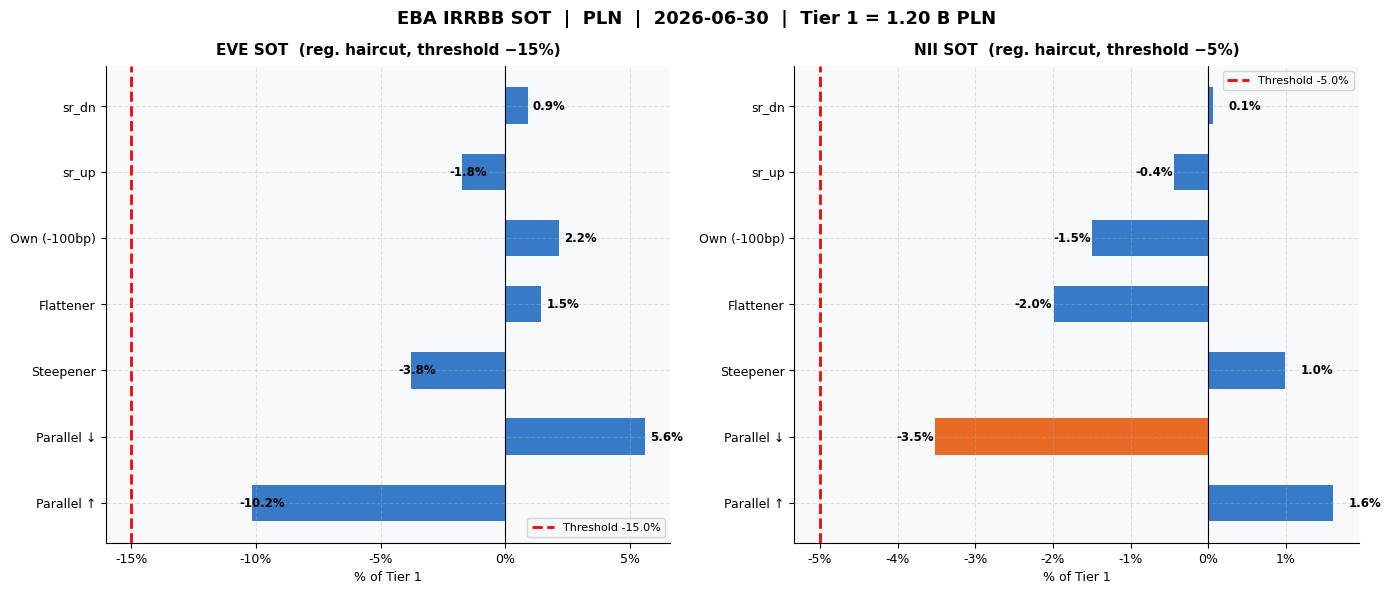

Scenario,ΔEVE (M),EVE%,EVE_reg%,ΔNII (M),NII%,NII_reg%,Breach
Parallel ↑,-122,-10.2%,-10.2%,+39,3.2%,1.6%,
Parallel ↓,+134,11.2%,5.6%,-42,-3.5%,-3.5%,
Steepener,-45,-3.8%,-3.8%,+24,2.0%,1.0%,
Flattener,+35,2.9%,1.5%,-24,-2.0%,-2.0%,
Own (-100bp),+52,4.4%,2.2%,-18,-1.5%,-1.5%,
sr_up,-21,-1.8%,-1.8%,-5,-0.4%,-0.4%,
sr_dn,+21,1.8%,0.9%,+2,0.1%,0.1%,


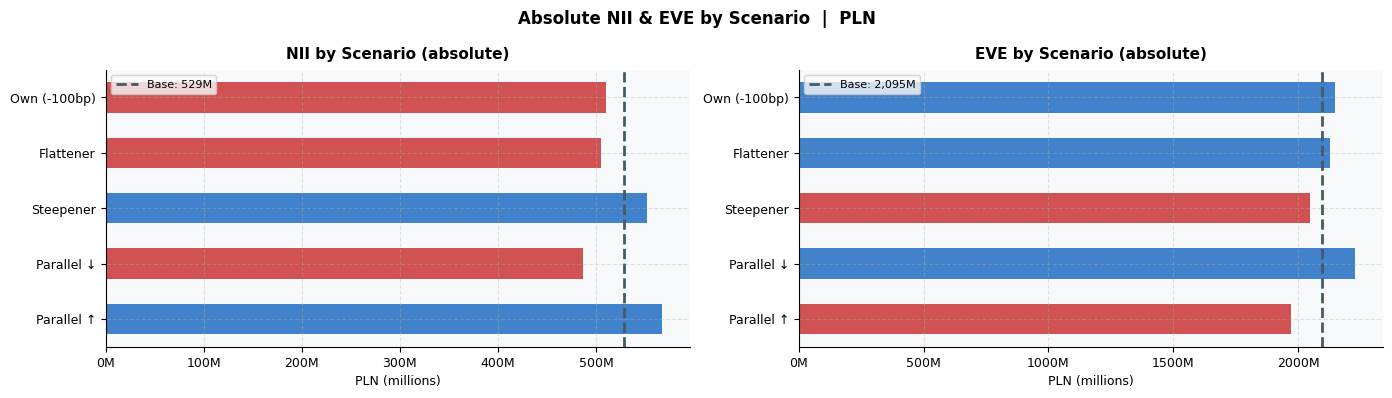

In [14]:
SID_ORDER = ['par_up', 'par_dn', 'steep', 'flat', 'short_up', 'short_dn', 'own']
SID_LABEL = {
    'par_up':   'Parallel ↑',
    'par_dn':   'Parallel ↓',
    'steep':    'Steepener',
    'flat':     'Flattener',
    'short_up': 'Short ↑',
    'short_dn': 'Short ↓',
    'own':      'Own (-100bp)',
}

if irrbb_sot.empty:
    print('No SOT data — run eba_sot_workflow first.')
else:
    sot = (irrbb_sot[irrbb_sot['currency'] == CCY].copy()
           .assign(order=lambda d: d['scenario_id'].map({s: i for i, s in enumerate(SID_ORDER)}))
           .sort_values('order').reset_index(drop=True))
    sot['label'] = sot['scenario_id'].map(SID_LABEL).fillna(sot['scenario_id'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'EBA IRRBB SOT  |  {CCY}  |  {REPORT_DATE.date()}'
                 f'  |  Tier 1 = {tier1/1e9:.2f} B PLN',
                 fontsize=13, fontweight='bold')

    def sot_bar(ax, df, col_pct, threshold, title):
        vals   = df[col_pct].fillna(0).tolist()
        labels = df['label'].tolist()
        y_pos  = np.arange(len(labels))
        colors = []
        for v in vals:
            if v < threshold:        colors.append(C_L)
            elif v < threshold * 0.7: colors.append(C_WN)
            else:                     colors.append(C_A)
        bars = ax.barh(y_pos, vals, color=colors, alpha=0.85, height=0.55)
        ax.axvline(threshold, color='red', lw=2, linestyle='--',
                   label=f'Threshold {threshold}%')
        ax.axvline(0, color='black', lw=0.8)
        for i, v in enumerate(vals):
            x_txt = v - 0.5 if v < 0 else v + 0.2
            ax.text(x_txt, i, f'{v:.1f}%', va='center', fontsize=8.5,
                    color='black', fontweight='bold')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
        ax.set_xlabel('% of Tier 1')
        ax.set_title(title)
        ax.legend()
        breach_n = sum(1 for v in vals if v < threshold)
        if breach_n:
            ax.text(0.98, 0.02, f'{breach_n} BREACH(ES)',
                    transform=ax.transAxes, ha='right', va='bottom',
                    color=C_L, fontweight='bold', fontsize=10)

    sot_bar(ax1, sot, 'sot_eve_pct_reg', -15.0, 'EVE SOT  (reg. haircut, threshold −15%)')
    sot_bar(ax2, sot, 'sot_nii_pct_reg', -5.0,  'NII SOT  (reg. haircut, threshold −5%)')

    plt.tight_layout()
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    _sot_rows = []
    for _, r in sot.iterrows():
        eve_breach = r.get('sot_eve_pct_reg', 0) < -15
        nii_breach = r.get('sot_nii_pct_reg', 0) < -5
        breach_txt = (('*** EVE' if eve_breach else '') + (' / NII' if nii_breach else '')).strip(' /')
        _sot_rows.append([
            r['label'],
            pos_neg(r.get('delta_eve', 0)/1e6, '+,.0f'),
            f"{r.get('sot_eve_pct', 0):.1f}%",
            (f"{r.get('sot_eve_pct_reg', 0):.1f}%", C_L if eve_breach else None),
            pos_neg(r.get('delta_nii', 0)/1e6, '+,.0f'),
            f"{r.get('sot_nii_pct', 0):.1f}%",
            (f"{r.get('sot_nii_pct_reg', 0):.1f}%", C_L if nii_breach else None),
            (breach_txt, C_L) if breach_txt else '',
        ])
    display(html_table(
        ['Scenario', 'ΔEVE (M)', 'EVE%', 'EVE_reg%', 'ΔNII (M)', 'NII%', 'NII_reg%', 'Breach'],
        _sot_rows,
        aligns=['left','right','right','right','right','right','right','left'],
        note=f'Tier 1 capital: {tier1/1e9:.3f} B PLN.',
    ))

    # ── NII & EVE absolute by scenario ────────────────────────────────────────
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 4))
    fig2.suptitle(f'Absolute NII & EVE by Scenario  |  {CCY}', fontsize=12, fontweight='bold')

    def abs_bar(ax, df_scen, col, title, base_sid='base'):
        d = df_scen[df_scen['currency'] == CCY].copy()
        base_val = float(d.loc[d['scenario_id'] == base_sid, col].sum() if base_sid in d['scenario_id'].values else 0)
        d = (d[d['scenario_id'].isin(SID_ORDER)]
             .assign(order=lambda x: x['scenario_id'].map({s: i for i, s in enumerate(SID_ORDER)}))
             .sort_values('order'))
        if d.empty: return
        vals_abs = d[col].tolist()
        y_pos = np.arange(len(vals_abs))
        colors = [C_A if v >= base_val else C_L for v in vals_abs]
        ax.barh(y_pos, [v/1e6 for v in vals_abs], color=colors, alpha=0.8, height=0.55)
        ax.axvline(base_val/1e6, color=C_GR, lw=2, linestyle='--',
                   label=f'Base: {base_val/1e6:,.0f}M')
        ax.set_yticks(y_pos)
        ax.set_yticklabels([SID_LABEL.get(s, s) for s in d['scenario_id']])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
        ax.set_xlabel('PLN (millions)')
        ax.set_title(title)
        ax.legend()

    abs_bar(ax3, nii_scen, 'nii_total', 'NII by Scenario (absolute)')
    abs_bar(ax4, eve_scen, 'pv_total',  'EVE by Scenario (absolute)')
    plt.tight_layout()
    plt.show()

### Sensitivity Tornado (delta view)

Same NII/EVE-by-scenario data as above, re-sorted as a tornado of deltas vs base.


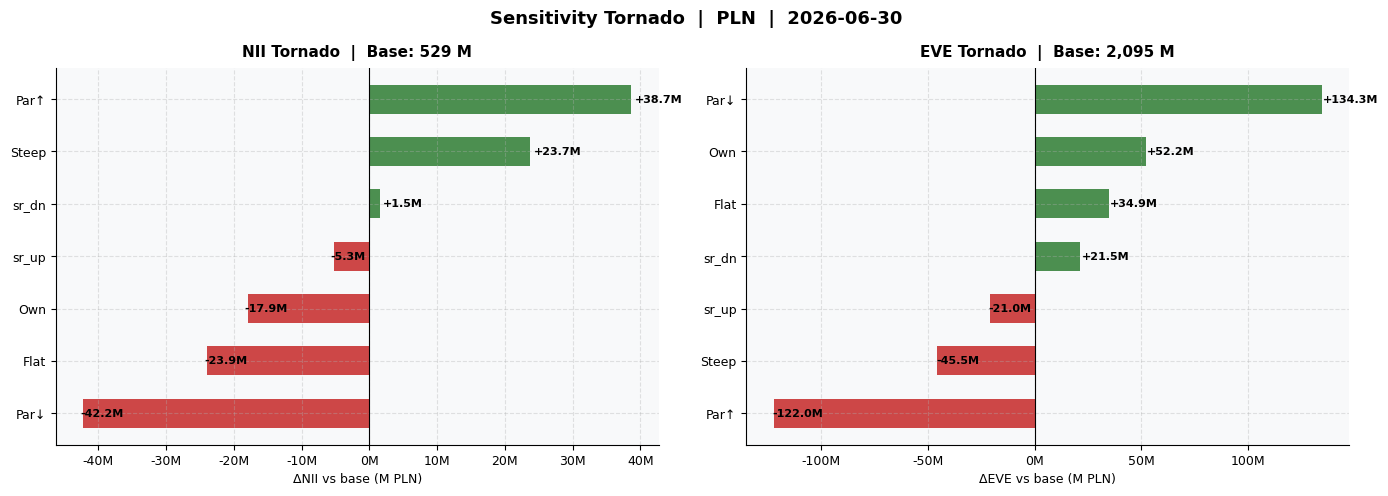

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# ADDITIONAL ALM VISUALIZATIONS
# NII & EVE tornado charts
# ─────────────────────────────────────────────────────────────────────────────
_SID_LBL = {'par_up':'Par↑','par_dn':'Par↓','steep':'Steep','flat':'Flat',
             'short_up':'Short↑','short_dn':'Short↓','own':'Own'}

nii_t = nii_scen[(nii_scen['currency'] == CCY) &
                  (nii_scen['scenario_id'] != 'base')].copy()
eve_t = eve_scen[(eve_scen['currency'] == CCY) &
                  (eve_scen['scenario_id'] != 'base')].copy()

has_nii = not nii_t.empty
has_eve = not eve_t.empty

if has_nii or has_eve:
    fig_t, axes_t = plt.subplots(1, 2, figsize=(14, 5))
    fig_t.suptitle(f'Sensitivity Tornado  |  {CCY}  |  {REPORT_DATE.date()}',
                   fontsize=13, fontweight='bold')

    base_nii_t = float(
        nii_scen[(nii_scen['currency'] == CCY) &
                 (nii_scen['scenario_id'] == 'base')]['nii_total'].sum()
    ) if 'base' in nii_scen['scenario_id'].values else 0.0
    base_eve_t = float(
        eve_scen[(eve_scen['currency'] == CCY) &
                 (eve_scen['scenario_id'] == 'base')]['pv_total'].sum()
    ) if 'base' in eve_scen['scenario_id'].values else 0.0

    def _tornado(ax, df, col, base_val, xlabel, title):
        df = df.copy()
        df['delta'] = df[col] - base_val
        df['label'] = df['scenario_id'].map(_SID_LBL).fillna(df['scenario_id'])
        df = df.sort_values('delta')
        y = np.arange(len(df))
        cols = [C_OK if v >= 0 else C_L for v in df['delta']]
        ax.barh(y, df['delta'] / 1e6, color=cols, alpha=0.85, height=0.55)
        ax.axvline(0, color='black', lw=0.8)
        for i, v in enumerate(df['delta']):
            offset = 0.5 if v >= 0 else -0.5
            ax.text(v/1e6 + offset, i, f'{v/1e6:+.1f}M',
                    va='center', fontsize=8, fontweight='bold')
        ax.set_yticks(y)
        ax.set_yticklabels(df['label'].tolist())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
        ax.set_xlabel(xlabel)
        ax.set_title(title)

    if has_nii:
        _tornado(axes_t[0], nii_t, 'nii_total', base_nii_t,
                 'ΔNII vs base (M PLN)', f'NII Tornado  |  Base: {base_nii_t/1e6:,.0f} M')
    else:
        axes_t[0].text(0.5, 0.5, 'No NII data', transform=axes_t[0].transAxes,
                       ha='center', va='center')

    if has_eve:
        _tornado(axes_t[1], eve_t, 'pv_total', base_eve_t,
                 'ΔEVE vs base (M PLN)', f'EVE Tornado  |  Base: {base_eve_t/1e6:,.0f} M')
    else:
        axes_t[1].text(0.5, 0.5, 'No EVE data', transform=axes_t[1].transAxes,
                       ha='center', va='center')

    plt.tight_layout()
    plt.show()
else:
    print('No NII/EVE scenario data available for tornado chart.')

---
## 10. Non-linearity Analysis (NII & EVE)

Interest-rate sensitivity **is not linear**: a shock twice as large does not produce exactly twice the P&L impact due to convexity, floors/caps, and optionality.

This section tests linearity by comparing:
- **Linear proxy**: ±1 bps sensitivity × 100 or × 250
- **Exact result**: full revaluation under ±100 bps and ±250 bps (EBA parallel)

The scatter plots show ΔEVE and ΔNII against shock size; the dashed line is the ±1 bps linear extrapolation. Deviation from this line reveals convexity.


Metric,Shock,Linear (M),Exact (M),Diff (M),Diff%
EVE,+1,-0.4,-0.4,+0.0,+0.0%
EVE,-1,+0.6,+0.6,+0.0,+0.0%
NII,+1,+0.2,+0.2,+0.0,+0.0%
NII,-1,-0.2,-0.2,+0.0,+0.0%
EVE,+100,-41.9,-50.1,-8.2,-16.4%
EVE,-100,+60.4,+52.2,-8.2,-15.7%
EVE,+250,-104.7,-122.0,-17.2,-14.2%
EVE,-250,+151.1,+134.3,-16.8,-12.5%
NII,+100,+23.2,+18.3,-4.8,-26.4%
NII,-100,-15.7,-20.5,-4.8,-23.6%


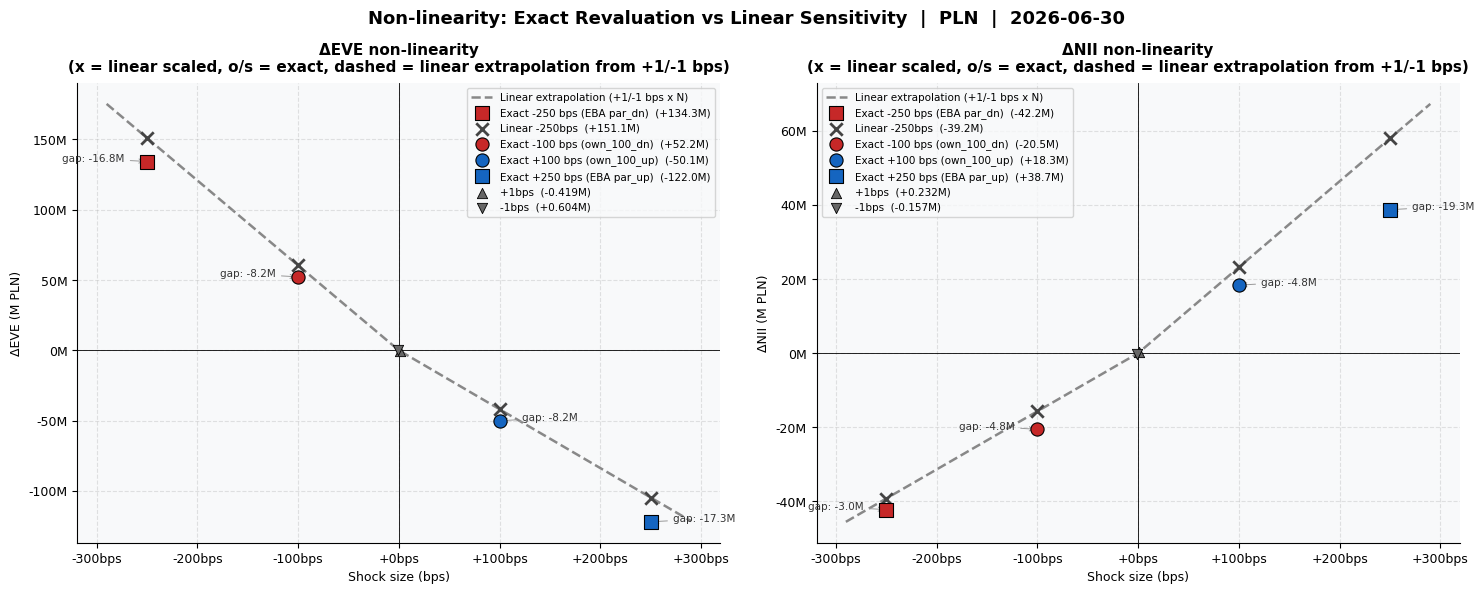

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-LINEARITY ANALYSIS  — ±1 bps × 100/250  vs exact ±100 / ±250 bps
# ─────────────────────────────────────────────────────────────────────────────
_ccy = CCY

def _get(df, sid, col):
    if df.empty: return 0.0
    sub = df[(df['scenario_id'] == sid) & (df['currency'] == _ccy)]
    return float(sub[col].sum()) if not sub.empty else 0.0

# Base
_nii_base = _get(nii_scen, 'base', 'nii_total')
_eve_base  = _get(eve_scen, 'base', 'pv_total')
# CF-table base: same pipeline as nii_own -> use for 1bps delta
_nii_cf_base = _get(nii_cf_base, 'base', 'nii_total') if not nii_cf_base.empty else _nii_base

# ±1 bps absolute NII / EVE from own scenarios
_nii_1up = _get(nii_own, 'own_1_up', 'nii_total')
_nii_1dn = _get(nii_own, 'own_1_dn', 'nii_total')
_eve_1up = _get(eve_own, 'own_1_up', 'pv_total')
_eve_1dn = _get(eve_own, 'own_1_dn', 'pv_total')

# ±1 bps deltas — use CF-table base for NII (consistent pipeline)
_dnii_1up = _nii_1up - _nii_cf_base
_dnii_1dn = _nii_1dn - _nii_cf_base
_deve_1up = _eve_1up - _eve_base
_deve_1dn = _eve_1dn - _eve_base

# ±100 bps exact (own scenarios)
_nii_100up = _get(nii_own, 'own_100_up', 'nii_total') - _nii_base
_nii_100dn = _get(nii_own, 'own_100_dn', 'nii_total') - _nii_base
_eve_100up = _get(eve_own, 'own_100_up', 'pv_total')  - _eve_base
_eve_100dn = _get(eve_own, 'own_100_dn', 'pv_total')  - _eve_base

# ±250 bps exact (EBA par_up / par_dn — PLN shock = 250 bps)
_nii_250up = _get(nii_scen, 'par_up', 'nii_total') - _nii_base
_nii_250dn = _get(nii_scen, 'par_dn', 'nii_total') - _nii_base
_eve_250up = _get(eve_scen, 'par_up', 'pv_total')  - _eve_base
_eve_250dn = _get(eve_scen, 'par_dn', 'pv_total')  - _eve_base

# ─── Non-linearity summary table ─────────────────────────────────────────────────────────────
_rows = []
# +1 bps and -1 bps explicit rows
for metric, d1up, d1dn in [
    ('EVE', _deve_1up, _deve_1dn),
    ('NII', _dnii_1up, _dnii_1dn),
]:
    for bps, exact in [(+1, d1up), (-1, d1dn)]:
        _rows.append({
            'Metric':           metric,
            'Shock (bps)':      f'{bps:+d}',
            'Linear 1bp*N (M)': round(exact / 1e6, 3),
            'Exact (M)':        round(exact / 1e6, 3),
            'Diff (M)':         0.0,
            'Diff (%)':         0.0,
        })
for metric, d1up, d1dn, ex100up, ex100dn, ex250up, ex250dn in [
    ('EVE', _deve_1up, _deve_1dn, _eve_100up, _eve_100dn, _eve_250up, _eve_250dn),
    ('NII', _dnii_1up, _dnii_1dn, _nii_100up, _nii_100dn, _nii_250up, _nii_250dn),
]:
    for bps, lin1, exact in [
        (+100, d1up, ex100up), (-100, d1dn, ex100dn),
        (+250, d1up, ex250up), (-250, d1dn, ex250dn),
    ]:
        lin_scaled = lin1 * abs(bps)  # lin1 is signed delta; abs(bps) scales magnitude
        diff       = exact - lin_scaled
        diff_pct   = diff / abs(exact) * 100 if exact else float('nan')
        _rows.append({
            'Metric':           metric,
            'Shock (bps)':      f'{bps:+d}',
            'Linear 1bp*N (M)': round(lin_scaled / 1e6, 2),
            'Exact (M)':        round(exact       / 1e6, 2),
            'Diff (M)':         round(diff        / 1e6, 2),
            'Diff (%)':         round(diff_pct,    2),
        })

_tbl = pd.DataFrame(_rows)
_nl_rows = []
for _, r in _tbl.iterrows():
    pc = r['Diff (%)']
    pc_s = f'{pc:+.1f}%' if not pd.isna(pc) else 'n/a'
    _nl_rows.append([
        r['Metric'], r['Shock (bps)'],
        pos_neg(r['Linear 1bp*N (M)'], '+.1f'), pos_neg(r['Exact (M)'], '+.1f'),
        pos_neg(r['Diff (M)'], '+.1f'), pc_s,
    ])
display(html_table(
    ['Metric', 'Shock', 'Linear (M)', 'Exact (M)', 'Diff (M)', 'Diff%'],
    _nl_rows,
    aligns=['left','right','right','right','right','right'],
    title=f'Non-linearity Table  |  {CCY}  |  {REPORT_DATE.date()}',
    note=f'Base NII: {_nii_base/1e6:+,.1f} M PLN    Base EVE: {_eve_base/1e6:+,.1f} M PLN',
))

# ─── Scatter plots: EVE and NII non-linearity ─────────────────────────────────────────────────
_pts = {
    'EVE': {-250: _eve_250dn, -100: _eve_100dn, -1: _deve_1dn,
            +1: _deve_1up, +100: _eve_100up, +250: _eve_250up},
    'NII': {-250: _nii_250dn, -100: _nii_100dn, -1: _dnii_1dn,
            +1: _dnii_1up, +100: _nii_100up, +250: _nii_250up},
}
_EXACT_MARKERS = {
    -250: ('s', C_L,  'Exact -250 bps (EBA par_dn)'),
    -100: ('o', C_L,  'Exact -100 bps (own_100_dn)'),
    +100: ('o', C_A,  'Exact +100 bps (own_100_up)'),
    +250: ('s', C_A,  'Exact +250 bps (EBA par_up)'),
}

fig3, (ax_e, ax_n) = plt.subplots(1, 2, figsize=(15, 6))
fig3.suptitle(
    f'Non-linearity: Exact Revaluation vs Linear Sensitivity  |  {CCY}  |  {REPORT_DATE.date()}',
    fontsize=13, fontweight='bold')

for ax, metric, ylabel in [(ax_e, 'EVE', 'ΔEVE (M PLN)'), (ax_n, 'NII', 'ΔNII (M PLN)')]:
    pts = _pts[metric]
    _bps_x = np.linspace(-290, 290, 500)

    # Linear reference: piecewise through ±1 bps points
    _slope_up = pts.get(+1, 0.0)
    _slope_dn = pts.get(-1, 0.0)
    _lin_y = np.where(_bps_x >= 0,
                      _bps_x * _slope_up / 1e6,
                      _bps_x * (-_slope_dn) / 1e6)
    ax.plot(_bps_x, _lin_y, color='#888888', lw=1.8, ls='--',
            label='Linear extrapolation (+1/-1 bps x N)', zorder=1)
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)

    # Plot exact points
    for bps in [-250, -100, +100, +250]:
        mk, col_m, lbl_m = _EXACT_MARKERS[bps]
        val = pts.get(bps, 0.0)
        ax.scatter(bps, val / 1e6, marker=mk, color=col_m, s=90, zorder=4,
                   edgecolors='black', linewidths=0.8,
                   label=f'{lbl_m}  ({val/1e6:+.1f}M)')

        # Corresponding linear approximation (cross marker)
        lin_val = (pts.get(+1, 0.0) * bps if bps > 0
                   else pts.get(-1, 0.0) * abs(bps))
        _lin_lbl = f'Linear {bps:+d}bps  ({lin_val/1e6:+.1f}M)' if bps == -250 else '_'
        ax.scatter(bps, lin_val / 1e6, marker='x', color='#444444', s=80,
                   linewidths=2.0, zorder=3, label=_lin_lbl)

        # Annotation: convexity gap (exact - linear)
        gap = val - lin_val
        if abs(gap) > 0.1e6:
            x_off = 22 if bps > 0 else -22
            ax.annotate(f'gap: {gap/1e6:+.1f}M',
                        xy=(bps, val / 1e6),
                        xytext=(bps + x_off, val / 1e6),
                        fontsize=7.5, color='#333333',
                        ha='left' if bps > 0 else 'right',
                        arrowprops=dict(arrowstyle='->', color='#999999', lw=0.7))

    # ±1 bps points (small markers)
    for b1 in [+1, -1]:
        v1 = pts.get(b1, 0.0)
        ax.scatter(b1, v1 / 1e6, marker='^' if b1 > 0 else 'v',
                   color='#666666', s=55, zorder=3, edgecolors='black', lw=0.6,
                   label=('+1bps' if b1 > 0 else '-1bps') + f'  ({v1/1e6:+.3f}M)')

    _metric_lbl = 'ΔEVE' if metric == 'EVE' else 'ΔNII'
    _title_line2 = '(x = linear scaled, o/s = exact, dashed = linear extrapolation from +1/-1 bps)'
    ax.set_title(f'{_metric_lbl} non-linearity\n' + _title_line2)
    ax.set_xlabel('Shock size (bps)')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}bps'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.show()

---
## 8. LCR & NSFR

- **LCR** = HQLA / Net outflows over 30 days — minimum **100 %**.  
- **NSFR** = Available Stable Funding (ASF) / Required Stable Funding (RSF) — minimum **100 %**.

In [17]:
if lcr_nsfr.empty:
    print('LCR/NSFR data not available. Run lcr_nsfr_workflow first.')
else:
    _cards = []
    for _, r in lcr_nsfr.sort_values('currency').iterrows():
        ccy    = str(r.get('currency', ''))
        lcr_p  = r.get('lcr', 0) * 100
        nsfr_p = (r.get('asf', 0) / r.get('rsf', 1)) * 100 if r.get('rsf', 0) > 0 else 0
        _cards.append({'label': f'LCR — {ccy}', 'value': f'{lcr_p:.0f}%',
                        'sub': 'min 100%', 'color': C_N if lcr_p >= 100 else C_L})
        _cards.append({'label': f'NSFR — {ccy}', 'value': f'{nsfr_p:.0f}%',
                        'sub': 'min 100%', 'color': C_N if nsfr_p >= 100 else C_L})
    display(kpi_row(_cards))